# The Plateau Knows: Early-Warning Signals for Grokking Under Reinforcement Learning

**Reproducibility package for a NeurIPS-style empirical study -- round 3.**

Two known precursors to *supervised* grokking — calibration/entropy dynamics and
effective-rank trajectories — were discovered where the training signal is a dense,
differentiable cross-entropy gradient. RL-induced grokking (as documented in
*"RL Grokking Recipe"*, Sun et al., ICLR 2026) uses a categorically different signal:
a sparse, often binary, non-differentiable reward. **This notebook asks whether any of
four candidate signals — policy entropy, reward variance, effective rank of policy
hidden states, and KL-divergence from a reference policy — measured only during the
early, near-zero-reward plateau, can discriminate RL training runs that go on to break
through from runs that stall permanently.**

**Where this stands, stated plainly rather than led with the best number we've ever
seen:** round 2 pre-registered `reward_variance` as the primary signal, based on a
promising round-1 pilot (n=16, AUROC 0.82-0.85). Under a properly powered, pre-registered
test (n=48), it did not replicate -- AUROC 0.627, 95% CI [0.312, 0.912], p=0.32; the
pilot result was small-sample noise, not a real effect. That is reported as the honest
outcome of round 2, not smoothed over. Round 2 also surfaced two signals that were
*never* pre-registered but showed strong, Bonferroni-surviving associations:
`effective_rank` (AUROC 0.72-0.75, continuous-outcome Spearman r=0.64-0.66, p<0.0001 at
every window tested) and `policy_entropy` (low entropy predicts breakthrough; r=-0.65
to -0.71, p<0.0001). Those are exploratory findings by this project's own stated
methodology -- promising, not confirmed. **This round pre-registers `effective_rank` @
window=0.1 as a genuine confirmatory test**, on a fresh batch of seeds (24-47) that
played no part in selecting it, and adds a partial-correlation analysis (Section 8.4)
testing whether it predicts breakthrough beyond simply knowing the run's current raw
reward -- the most direct available answer to "is this just reward in disguise."

This notebook is fully self-contained: every model, task, and dataset is generated or
downloaded automatically. It is designed for a single NVIDIA T4 GPU (Kaggle Notebook,
~12-hour budget) and is resumable — if the runtime disconnects partway through, re-running
the notebook from the top will detect and reuse everything already completed.

**Honest scope note (read before running):** the core experiment trains a small
transformer via a brief supervised warmup (to a genuine, non-degenerate starting point —
see Section 3 for why pure policy-gradient learning from a randomly-initialized model
doesn't work) followed by policy-gradient training on synthetic algorithmic tasks — the
same scale of setup as the supervised-grokking literature this project extends, not a
production RLVR pipeline. An optional stretch section repeats a reduced version of the
design with a small pretrained LM (Qwen2.5-0.5B) as a first, partial check on whether
findings transfer beyond the toy setting. The toy-scale scoping, the warmup-phase design
choice, and the stretch check's limitations are all discussed explicitly in Sections 3,
7, and 10 — this notebook does not overclaim what a T4-scale toy experiment can and
cannot show.

## Section 1 — Environment Setup

Installs pinned dependencies, detects hardware, fixes random seeds, and validates the
environment. **Execution stops with a clear error if a GPU is unavailable** (per the
compute-budget requirements this notebook was designed against) — Kaggle Notebooks:
Settings → Accelerator → GPU T4 x2 (only GPU 0 is used; see Section 2).

In [1]:
#@title 1.1 Install dependencies (idempotent — skips anything already satisfied)
import importlib, subprocess, sys

REQUIRED = [
    ("torch", "torch"),
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("sklearn", "scikit-learn"),
    ("scipy", "scipy"),
    ("tqdm", "tqdm"),
]

def ensure(import_name, pip_name):
    try:
        importlib.import_module(import_name)
        return True
    except ImportError:
        pass
    print(f"Installing {pip_name} ...")
    # Try a plain install first (the normal case on Kaggle/Colab); fall back to
    # --user, then --break-system-packages, for environments that enforce
    # PEP 668's externally-managed-environment restriction. Each fallback is
    # only attempted if the previous one actually failed.
    attempts = [
        [sys.executable, "-m", "pip", "install", "-q", pip_name],
        [sys.executable, "-m", "pip", "install", "-q", "--user", pip_name],
        [sys.executable, "-m", "pip", "install", "-q", "--break-system-packages", pip_name],
    ]
    last_error = None
    for attempt in attempts:
        result = subprocess.run(attempt, capture_output=True, text=True)
        if result.returncode == 0:
            importlib.invalidate_caches()
            importlib.import_module(import_name)
            return False
        last_error = result.stderr
    raise RuntimeError(f"Could not install {pip_name} after trying plain/--user/--break-system-packages "
                        f"pip install. Last error:\n{last_error}")

for import_name, pip_name in REQUIRED:
    ensure(import_name, pip_name)

# Optional: transformers/peft are only needed for the Section 10 stretch check
# (small pretrained LM). Installed lazily there, not here, so the core
# experiment never depends on them.
print("Core dependencies satisfied.")

Core dependencies satisfied.


In [2]:
#@title 1.2 GPU / CUDA detection (hard stop if unavailable)
import torch, platform, os, sys, random, time
import numpy as np

_NOTEBOOK_START_TIME = time.time()  # used by Section 12's profiling and Section 7's budget checks

if not torch.cuda.is_available():
    raise RuntimeError(
        "No CUDA GPU detected. This notebook is designed for a single NVIDIA T4 GPU "
        "(Kaggle: Settings -> Accelerator -> GPU T4 x2, or Colab: Runtime -> Change "
        "runtime type -> GPU). Enable a GPU and re-run from the top."
    )

DEVICE = torch.device("cuda:0")
GPU_NAME = torch.cuda.get_device_name(0)
GPU_MEM_GB = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f"Python:        {platform.python_version()}")
print(f"OS:            {platform.platform()}")
print(f"PyTorch:       {torch.__version__}")
print(f"CUDA (torch):  {torch.version.cuda}")
print(f"GPU:           {GPU_NAME}")
print(f"GPU memory:    {GPU_MEM_GB:.1f} GB")

import pandas as pd
import matplotlib, sklearn, scipy
print(f"numpy:         {np.__version__}")
print(f"pandas:        {pd.__version__}")
print(f"matplotlib:    {matplotlib.__version__}")
print(f"scikit-learn:  {sklearn.__version__}")
print(f"scipy:         {scipy.__version__}")

if "T4" not in GPU_NAME:
    print(f"\nNOTE: this notebook was tuned against a T4's throughput. Detected "
          f"'{GPU_NAME}' instead -- runtime estimates in Section 2 may be off; the "
          f"auto-calibration step in Section 7 re-measures actual throughput and "
          f"adjusts the step budget accordingly, so this is informational, not fatal.")

Python:        3.12.13
OS:            Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch:       2.10.0+cu128
CUDA (torch):  12.8
GPU:           Tesla T4
GPU memory:    15.6 GB
numpy:         2.0.2
pandas:        2.3.3
matplotlib:    3.10.0
scikit-learn:  1.6.1
scipy:         1.16.3


In [3]:
#@title 1.3 Deterministic execution settings
import torch, random, numpy as np

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# A base seed for anything not explicitly seeded per-run below (per-run seeds
# are set independently inside the training loop, see Section 7).
set_global_seed(0)

# Full bitwise determinism is not requested: cuDNN benchmark mode is left on
# for speed (this notebook's model is tiny enough that autotuning overhead
# would otherwise dominate short runs), which trades exact bit-reproducibility
# for a documented, seed-controlled *statistical* reproducibility instead --
# i.e. re-running with the same seed reproduces the same task instances, same
# initial weights, and the same sampling *distribution*, but not necessarily
# bit-identical floating point sums on GPU. This is stated explicitly rather
# than silently claimed away.
torch.backends.cudnn.benchmark = True
print("Deterministic seeding configured (statistical, not bitwise -- see comment above).")

Deterministic seeding configured (statistical, not bitwise -- see comment above).


## Section 2 — Configuration Management

A single configuration object every downstream cell reads from. Saved to
`outputs/configs/config.json` immediately, and re-loaded (not re-created) on any
resumed run so that a resumed run cannot silently drift from the configuration that
started it.

In [4]:
#@title 2.1 Central configuration
import dataclasses, json, os, hashlib
from pathlib import Path

@dataclasses.dataclass
class Config:
    # --- run control ---
    resume: bool = True          # reuse any artifacts already on disk
    overwrite: bool = False      # force regeneration of everything
    max_total_hours: float = 11.0  # hard ceiling this notebook will self-throttle to
                                    # (kept under the 12h nominal budget as a safety margin
                                    # for setup/figure/zip overhead)

    # --- output locations ---
    output_dir: str = "outputs"
    cache_dir: str = "outputs/cache"
    checkpoint_dir: str = "outputs/checkpoints"
    config_dir: str = "outputs/configs"
    figures_dir: str = "outputs/figures"
    tables_dir: str = "outputs/tables"
    logs_dir: str = "outputs/logs"
    metrics_dir: str = "outputs/metrics"
    environment_dir: str = "outputs/environment"
    summaries_dir: str = "outputs/summaries"

    # --- model ---
    d_model: int = 128
    n_heads: int = 4
    n_layers: int = 4
    d_ff: int = 512
    max_seq_len: int = 16

    # --- GRPO / optimization ---
    # Weight decay is set high, matching the supervised-grokking literature's
    # well-documented finding that strong weight decay is what makes the delayed
    # transition happen at all under AdamW (Power et al. 2022; see Section 3).
    # NOTE: this convention is specifically a supervised-learning finding; the
    # RL phase below uses its own, separately-configured weight decay
    # (grpo_weight_decay) rather than assuming it transfers.
    lr: float = 2e-3
    weight_decay: float = 0.5
    grpo_weight_decay: float = 0.05   # RL fine-tuning phase uses a much lower
                                       # decay than the supervised-grokking
                                       # convention above -- REINFORCE-style
                                       # gradients are far noisier than dense
                                       # cross-entropy ones, and strong decay
                                       # tuned for the latter is not assumed to
                                       # transfer without evidence it helps here.
    grad_clip: float = 1.0
    entropy_coef: float = 0.05        # standard small entropy bonus for the RL phase --
                                       # without it, sampling entropy collapses early
                                       # (observed directly during debugging: as entropy
                                       # falls, more groups sample the same token for
                                       # every rollout, zeroing that group's own reward
                                       # variance and therefore its gradient contribution
                                       # -- a self-reinforcing spiral with no corrective
                                       # pressure once it starts). This means the policy
                                       # entropy SIGNAL this project studies is no longer
                                       # entirely free/unregularized -- a limitation to
                                       # keep in mind when interpreting its discriminative
                                       # power specifically, not a reason to omit the term
                                       # and have nothing to study at all.
    prompts_per_step: int = 64
    group_size: int = 16
    sample_temperature: float = 0.9
    total_steps: int = 10000          # Task A GRPO phase, starting point for joint
                                       # calibration (Section 7.2).
    secondary_total_steps: int = 15000  # Task B GRPO phase, starting point -- 1.5x
                                       # Task A's. Task B requires TWO independent
                                       # correct tokens, so its random-chance success
                                       # rate is ~23x rarer than Task A's single-token
                                       # target; a fair chance at comparable breakthrough
                                       # rates needs proportionally more runway, not the
                                       # same budget. Joint calibration scales both of
                                       # these down TOGETHER (preserving this 1.5x ratio)
                                       # if they don't jointly fit max_total_hours.
    warmup_fraction: float = 0.3      # two_phase schedule only, within the GRPO phase.
                                       # Reverted toward the original value now that
                                       # supervised_warmup (below) handles most of
                                       # "getting the policy into a workable regime" --
                                       # this fraction now only controls how long GRPO
                                       # itself stays in dense-reward mode.

    # --- supervised warmup, run once per seed before GRPO ---
    # RL Grokking Recipe fine-tunes an already-capable pretrained model; it never
    # learns a task from a randomly-initialized model using reward alone. Pure
    # REINFORCE/GRPO from random init has to bootstrap entirely from whatever the
    # model happens to sample -- with no dense per-step supervisory signal, this
    # is a far harder exploration problem than either real RLVR (refining an
    # already-decent policy) or supervised grokking (an exact, dense gradient
    # that needs no exploration). This phase gives the RL phase a genuine,
    # non-degenerate starting point, the same way real RLVR always starts from an
    # SFT model rather than a random one -- run once per seed, then BOTH schedules
    # branch from an identical copy of that warmed-up policy, so the two_phase vs.
    # binary_only comparison isn't confounded by two independent warmup runs.
    supervised_warmup_steps: int = 3000       # generous cap; early-stopped by target below
    supervised_warmup_target_accuracy: float = 0.6  # stop early once reached -- leaves
                                                      # real room for the RL phase to do
                                                      # something, rather than handing it
                                                      # an already-solved task
    supervised_warmup_lr: float = 3e-3
    supervised_warmup_weight_decay: float = 0.01
    supervised_warmup_batch_size: int = 128
    success_threshold: float = 0.9
    success_window: int = 100
    signal_log_every: int = 50
    checkpoint_every_steps: int = 500

    # --- experiment grid ---
    # ROUND 3 (this config). History, stated plainly rather than buried:
    #   Round 1 (8 seeds):  pilot. reward_variance looked best (AUROC 0.82-0.85).
    #   Round 2 (24 seeds): pre-registered reward_variance @ window=0.3 as the
    #     confirmatory primary. IT DID NOT REPLICATE -- AUROC 0.627, 95% CI
    #     [0.312, 0.912], p=0.32; continuous-outcome Spearman r=0.230, CI
    #     [-0.085, 0.526], p=0.11. Both intervals cross chance/zero. The
    #     round-1 result was optimistic small-sample noise (n=16, 3
    #     breakthroughs) -- this is pre-registration doing exactly its job:
    #     catching a result that looked strong and wasn't, before it became a
    #     paper's headline claim.
    #     Round 2 ALSO surfaced two signals that were never pre-registered but
    #     showed strong, Bonferroni-surviving effects: effective_rank (AUROC
    #     0.72-0.75, continuous r=0.64-0.66, p<0.0001 at every window) and
    #     policy_entropy (AUROC 0.18-0.23, i.e. low entropy predicts
    #     breakthrough, continuous r=-0.65 to -0.71, p<0.0001 at every
    #     window). Both are exploratory findings by this project's own stated
    #     methodology -- promising, not confirmed.
    #   Round 3 (this run): pre-registers effective_rank @ window=0.1 (best
    #     CI of the round-2 exploratory candidates) as a genuine confirmatory
    #     test, on a FRESH batch of seeds (24-47) not used to select it. This
    #     is the test that actually earns the word "pre-registered" for this
    #     signal -- round 2's version of this same signal was still
    #     exploratory relative to round 1's data.
    # seeds now spans BOTH the original round-2 batch (0-23, kept -- their
    # checkpoints remain valid and are not retrained, see training_hash()
    # below) and the new confirmatory batch (24-47).
    seeds: tuple = tuple(range(48))
    # Task B is deliberately NOT extended to match. It already returned a
    # clean, well-powered null at 24 seeds (0/48 runs broke through even at
    # 1.5x Task A's steps) -- that's an answered question, not an underpowered
    # one, and it isn't part of what round 3 is confirming. Doubling it again
    # would cost several more hours for no evidence toward the actual primary
    # hypothesis. secondary_seeds intentionally stays at the round-2 value.
    secondary_seeds: tuple = tuple(range(24))
    schedules: tuple = ("two_phase", "binary_only")
    task_names: tuple = ("task_a_single_token", "task_b_two_token")
    primary_task: str = "task_a_single_token"   # used for the main sweep (Sec 7-9);
                                                 # the second task is the cross-task
                                                 # robustness check (Sec 10)

    # --- signal analysis ---
    early_window_fractions: tuple = (0.1, 0.2, 0.3)
    n_bootstrap: int = 2000

    # --- pre-registration (ROUND 3) ---
    # effective_rank @ window=0.1 was round 2's best-performing, tightest-CI
    # EXPLORATORY result (AUROC 0.750, CI [0.594, 0.884], survived Bonferroni
    # on the continuous-outcome test at p<0.0001). Selecting it for
    # confirmation is informed by round 2's data, same honesty caveat as
    # before: this is confirmatory relative to the FRESH seeds (24-47) that
    # will actually decide it, not a blind first guess. If it replicates
    # here, it graduates from "exploratory" to "confirmed" for the first
    # time in this project. If it doesn't, that's reported exactly as
    # plainly as reward_variance's round-2 failure was.
    primary_signal: str = "effective_rank"
    primary_window_fraction: float = 0.1

    # --- stretch check (Section 10) ---
    run_pretrained_stretch: bool = True
    stretch_model_name: str = "Qwen/Qwen2.5-0.5B-Instruct"
    stretch_total_steps: int = 800
    stretch_seeds: tuple = (0, 1, 2)

    def hash(self) -> str:
        """Full-config hash -- used only for the config.json change-detection
        print below (informational: did ANYTHING change since last session).
        NOT used for checkpoint validation -- see training_hash()."""
        payload = json.dumps(dataclasses.asdict(self), sort_keys=True, default=str)
        return hashlib.sha256(payload.encode()).hexdigest()[:16]

    # Fields that actually change what a specific (task, schedule, seed) run
    # would produce if retrained. Deliberately EXCLUDES: seeds/secondary_seeds
    # (the roster of WHICH runs to do says nothing about how any ONE of them
    # trains -- extending the roster must not invalidate runs already done),
    # primary_signal/primary_window_fraction/early_window_fractions/n_bootstrap
    # (pure analysis-time choices, computed AFTER training from saved logs),
    # stretch_* (a separate, independent check), and all path/run-control
    # fields. This is what makes it possible to add 24 confirmatory seeds
    # without retraining the 48 runs already on disk -- those checkpoints are
    # validated against this narrower hash, so a change to, say,
    # primary_window_fraction (or growing the seed tuple) cannot make them
    # look stale.
    _TRAINING_FIELDS = (
        "d_model", "n_heads", "n_layers", "d_ff", "max_seq_len",
        "lr", "weight_decay", "grpo_weight_decay", "grad_clip", "entropy_coef",
        "prompts_per_step", "group_size", "sample_temperature",
        "total_steps", "secondary_total_steps", "warmup_fraction",
        "supervised_warmup_steps", "supervised_warmup_target_accuracy",
        "supervised_warmup_lr", "supervised_warmup_weight_decay", "supervised_warmup_batch_size",
        "success_threshold", "success_window", "signal_log_every",
        "schedules", "task_names", "primary_task",
    )

    def training_hash(self) -> str:
        """Hash of only the fields that affect what a training run produces.
        This is what checkpoint validation (Section 7.1) actually uses."""
        payload = json.dumps({k: getattr(self, k) for k in self._TRAINING_FIELDS}, sort_keys=True, default=str)
        return hashlib.sha256(payload.encode()).hexdigest()[:16]


CFG = Config()

for d in [CFG.output_dir, CFG.cache_dir, CFG.checkpoint_dir, CFG.config_dir,
          CFG.figures_dir, CFG.tables_dir, CFG.logs_dir, CFG.metrics_dir,
          CFG.environment_dir, CFG.summaries_dir]:
    Path(d).mkdir(parents=True, exist_ok=True)

config_path = Path(CFG.config_dir) / "config.json"
if config_path.exists() and CFG.resume and not CFG.overwrite:
    with open(config_path) as f:
        saved = json.load(f)
    if saved.get("_hash") != CFG.hash():
        # Adopt the configuration this cell just defined -- NOT the old values on
        # disk. Per-run checkpoints are independently validated against CFG.hash()
        # at load time (Section 7.1's load_run_result_if_valid), so a config change
        # here cannot cause a stale checkpoint to be silently reused regardless of
        # what this cell does; the only question is which config plan takes effect
        # going forward, and that should be the one you just wrote into the notebook,
        # not a stale copy from an earlier session.
        changed = {
            k: (saved.get(k), v) for k, v in dataclasses.asdict(CFG).items()
            if saved.get(k) != v
        }
        print("Config changed since the last run on disk -- adopting the NEW values "
              "from this cell (old values on disk are being overwritten). Changed "
              "fields (old -> new):")
        for k, (old, new) in changed.items():
            print(f"  {k}: {old!r} -> {new!r}")
        print("Any checkpoint computed under the old configuration will be detected "
              "as stale by its own config-hash check and retrained automatically -- "
              "no manual cleanup needed.")
    else:
        print("Existing config.json matches this cell's configuration -- resuming.")

payload = dataclasses.asdict(CFG)
payload["_hash"] = CFG.hash()
with open(config_path, "w") as f:
    json.dump(payload, f, indent=2, default=str)

print(json.dumps(dataclasses.asdict(CFG), indent=2, default=str))

Existing config.json matches this cell's configuration -- resuming.
{
  "resume": true,
  "overwrite": false,
  "max_total_hours": 11.0,
  "output_dir": "outputs",
  "cache_dir": "outputs/cache",
  "checkpoint_dir": "outputs/checkpoints",
  "config_dir": "outputs/configs",
  "figures_dir": "outputs/figures",
  "tables_dir": "outputs/tables",
  "logs_dir": "outputs/logs",
  "metrics_dir": "outputs/metrics",
  "environment_dir": "outputs/environment",
  "summaries_dir": "outputs/summaries",
  "d_model": 128,
  "n_heads": 4,
  "n_layers": 4,
  "d_ff": 512,
  "max_seq_len": 16,
  "lr": 0.002,
  "weight_decay": 0.5,
  "grpo_weight_decay": 0.05,
  "grad_clip": 1.0,
  "entropy_coef": 0.05,
  "prompts_per_step": 64,
  "group_size": 16,
  "sample_temperature": 0.9,
  "total_steps": 10000,
  "secondary_total_steps": 15000,
  "warmup_fraction": 0.3,
  "supervised_warmup_steps": 3000,
  "supervised_warmup_target_accuracy": 0.6,
  "supervised_warmup_lr": 0.003,
  "supervised_warmup_weight_decay": 0

## Section 3 — Problem Definition

**Research motivation.** RLVR (RL from verifiable rewards) training runs routinely spend
long stretches with near-zero reward before a model either breaks through to strong
performance or never does. That plateau looks identical minute-to-minute regardless of
which outcome is coming, which means practitioners currently cannot tell "this run needs
more patience" from "this run needs a different reward schedule" without simply waiting
it out — an expensive way to find out.

**Core hypothesis.** Among four candidate signals, at least one — measured only during
the early plateau, before any visible reward movement — reliably discriminates
eventual-breakthrough runs from eventual-stall runs, at a lead time long enough to be
practically useful for early stopping.

**Mathematical formulation.** Policy $\pi_\theta$, prompts $x$ drawn from a synthetic
task distribution $\mathcal{T}$, reward $r(x, y)\in[0,1]$. We use group-relative policy
optimization (GRPO): for each $x$, sample a group of $G$ completions
$\{y_1,\dots,y_G\}\sim\pi_\theta(\cdot\mid x)$, and take the group-relative advantage

$$A_i = \frac{r(x, y_i) - \bar r_G}{\mathrm{sd}(r_G) + \varepsilon}, \qquad
\bar r_G = \tfrac{1}{G}\sum_j r(x,y_j)$$

with policy-gradient loss $\mathcal{L}(\theta) = -\mathbb{E}\big[A_i \cdot \log
\pi_\theta(y_i \mid x)\big]$ and no entropy bonus or KL penalty term (a deliberate scope
choice: two of the four candidate signals *are* policy entropy and KL-from-reference, so
directly optimizing for either would confound "is this signal informative" with "is this
signal being controlled by the objective").

**Reward schedules** (breakthrough vs. stall conditions, taken directly from what "RL
Grokking Recipe" documents as separating its two outcomes):
- `two_phase`: dense, distance-based partial credit for the first `warmup_fraction` of
  training, then binary (exact-match) reward for the remainder.
- `binary_only`: binary reward from step 0.

**Why `binary_only` should stall, mechanistically, not just empirically:** with reward
$r\in\{0,1\}$ and success probability on the order of 1% early in training, a large
fraction of groups will have *every* rollout fail ($r_i=0\ \forall i$), giving
$\mathrm{sd}(r_G)=0$ and therefore **exactly zero gradient signal** from that group. This
is the same "zero-variance prompt" phenomenon documented for agentic RL training more
broadly (RAGEN, RAGEN-2). The dense phase of `two_phase` sidesteps this because
distance-based partial credit varies across *wrong* answers, so groups retain nonzero
variance — and hence a usable gradient — even before any rollout is exactly correct.

**Two design revisions made after real GPU runs exposed them (documented here rather
than silently folded in, because both are informative about the method itself, not just
this codebase):**

1. *A supervised warmup phase, run once per seed before GRPO.* The original design ran
   GRPO from a randomly-initialized policy. A full 12,000- and then 30,000-step sweep on
   real hardware showed reward flat at the random-chance baseline in **both** reward
   phases, for every seed, on both schedules. The reason: "RL Grokking Recipe" — and real
   RLVR generally — always fine-tunes an already-capable pretrained model; it never
   learns a task from a randomly-initialized one using reward alone. Pure REINFORCE-style
   learning has to bootstrap entirely from whatever the model happens to sample, with no
   dense per-step signal about which token *should* have been output — a far harder
   exploration problem than either real RLVR (refining an already-decent policy) or
   supervised grokking (an exact, dense gradient needing no exploration at all). A brief
   supervised warmup (Section 2.1's `supervised_warmup_*` settings) now gives each seed's
   policy a genuine, non-degenerate starting point before GRPO begins — the RL phase is
   then responsible for refinement, which is what it's actually suited for, not
   bootstrapping from scratch. Both schedules for a given seed branch from an identical
   copy of that seed's warmed-up policy, so the two_phase-vs-binary_only comparison isn't
   confounded by two independent warmup runs.
2. *The task's input space, shrunk from three independent inputs to two, over a fixed
   finite pool.* The original Task A drew $(a,b,c)$ fresh from $[0,97)^3$ every batch —
   a ~913,000-point space. The classic supervised-grokking literature this project
   compares against (Power et al., 2022) uses a single binary operation over a **fixed**
   $97\times97=9{,}409$-pair space, repeatedly sampled from a fixed train subset — a
   design that's specifically what enables memorization-then-generalization dynamics to
   emerge in a tractable step budget. The 3-input version was diagnosed directly: even a
   *supervised* (non-RL) control on it showed the same flat, no-progress trajectory,
   which ruled out "RL specifically can't learn this" and pointed at insufficient
   exposure instead. Task A and Task B (Section 4.1) now both use the smaller, fixed,
   literature-matched space.

**Candidate signals**, all measured on a fixed evaluation probe (not the training batch,
so measurement does not disturb training):
1. **Policy entropy** — mean token-level entropy of $\pi_\theta$ on the probe.
2. **Reward variance** — mean within-group reward variance on the *training* batch
   (the one signal that is a property of training itself, not the fixed probe).
3. **Effective rank** — $\exp(H(p))$ where $p$ is the normalized singular-value spectrum
   of policy hidden states on the probe (Roy & Vetterli, 2007) — the direct RL-setting
   analogue of the effective-rank precursor for supervised grokking.
4. **KL-from-reference** — $D_{\mathrm{KL}}(\pi_\theta \,\|\, \pi_{\theta_0})$ against the
   frozen initial policy, on the probe.

**Falsifiable hypothesis, restated precisely:** for at least one signal $s$, the AUROC of
"mean value of $s$ over the first `window_fraction` of training" for predicting
`broke_through` is significantly above 0.5 (permutation test), at a window fraction small
enough to leave useful lead time before the visible reward transition. If no signal beats
chance at any tested window, the hypothesis is refuted — reported as such, not
reframed.

## Section 4 — Method

Modular implementation: synthetic tasks, a tiny causal-transformer policy, the GRPO
trainer, and the four signal computations, each in its own cell with a narrow, documented
interface, mirroring a small reusable library rather than a monolithic script.

This notebook writes its method code to a real `src/` package on disk (via `%%writefile`,
below) rather than pasting equivalent code into isolated cells, specifically so the
modules can import from each other normally (`model.py` imports nothing extra;
`signals.py` and `grpo.py` import from `model`, `tasks`, and each other) — the same
structure as, and directly reusable outside of, this notebook. `src/` is created once and
is idempotent to re-run: re-executing these cells just rewrites the same files.

#### 4.1 Synthetic task families

Two task families over a **fixed, finite** $97\times97=9{,}409$-pair space (matching the
classic supervised-grokking modulus and scale, Power et al., 2022) — a fixed train/test
split, seeded once and shared across every run, so results sit in the same scale/units
as the literature this work extends. (An earlier version drew three independent inputs
fresh each batch, a ~913,000-point effectively-unbounded space; that mismatch is exactly
what a real sweep diagnosed as flat, no-progress training regardless of RL vs. supervised
signal — see Section 3.)

- **Task A** (single-token answer, primary task for the main sweep): $y = (a\cdot b)
  \bmod 97$. A random policy succeeds with probability $1/97\approx1.03\%$.
- **Task B** (two dependent tokens, second task family for the Section 10 cross-task
  robustness check): $d_1=(a+b)\bmod 97$, $d_2=(a\cdot b)\bmod 23$ — a structurally
  different composition over the *same* $(a,b)$ pool; random-policy success probability
  $\approx (1/97)(1/23)\approx0.045\%$, and the only place multi-step (length > 1)
  generation is exercised.

In [5]:
#@title 4.0 Create the src/ package
import os
os.makedirs("src", exist_ok=True)
open("src/__init__.py", "a").close()
import sys
if "src" not in sys.path:
    sys.path.insert(0, "src")
print("src/ ready and on sys.path.")

src/ ready and on sys.path.


In [6]:
%%writefile src/tasks.py
"""
Synthetic algorithmic task families for RL-grokking experiments.

Design rationale (documented here so it travels with the code, and is
restated in the notebook's markdown):

  - Both tasks are defined over (a, b) pairs drawn from a FIXED, finite,
    seeded 97x97 = 9,409-pair space, with a fixed train/test split -- this
    now matches the classic supervised-grokking setup (Power et al., 2022)
    on purpose, not just in spirit. An earlier version of Task A used three
    independent inputs (a, b, c), which blows the space up to 97^3 ~= 913K --
    a ~97x larger space that the same step*batch exposure covers only ~1%
    as thoroughly. That mismatch was diagnosed directly: a 12,000- and then
    30,000-step real sweep showed reward flat at the random baseline in
    BOTH the dense and binary phases, and a supervised (non-RL) control
    on the 3-input version showed the same flatness -- i.e. it wasn't
    even a training-signal-type problem, it was an exposure problem. The
    two-input, fixed-split design below is deliberately the same scale the
    literature this project builds on has already validated converges in a
    tractable step budget.
  - The train/test split itself is fixed by a task-level seed shared across
    all training seeds/schedules -- every run sees the identical set of
    memorizable pairs; only model initialization and sampling stochasticity
    vary by run seed. This isolates "does training dynamics affect
    breakthrough timing" from "did this run happen to get an easier data
    split," which is the property grokking studies need from a train/test
    split.
  - TASK A (single-token): y = (a * b) mod 97, a random policy succeeds
    with probability 1/97 (~1.03%) per attempt.
  - TASK B (two-token): d1 = (a + b) mod 97, d2 = (a * b) mod P_SUB -- a
    genuinely different composition (different operations, an added
    modulus) over the SAME (a, b) input space, so the two task families are
    comparable in scale while remaining structurally distinct. Requires two
    dependent correct predictions, so a random policy succeeds with
    probability (1/97) * (1/P_SUB); this is the only place actual
    autoregressive (length > 1) generation is exercised.

Both tasks expose the same interface: a Task object that can (a) sample a
batch of prompts from a given split, (b) score a batch of candidate answers
against a dense (graded) or binary reward, and (c) render prompts/answers to
token ids for the model.
"""
from __future__ import annotations

import dataclasses
from typing import Literal

import numpy as np
import torch

RewardMode = Literal["dense", "binary"]
Split = Literal["train", "test"]


# ---------------------------------------------------------------------------
# Vocabulary
# ---------------------------------------------------------------------------
P_MAIN = 97   # matches Power et al. 2022's classic modulus
P_SUB = 23    # second modulus used only by Task B's second digit

PAD, BOS, PLUS, TIMES, EQUALS = range(P_MAIN, P_MAIN + 5)
VOCAB_SIZE = P_MAIN + 5  # special tokens fit inside the same table as P_MAIN numerals

TRAIN_TEST_SPLIT_SEED = 1234    # fixed across all runs -- see module docstring
DEFAULT_TRAIN_FRACTION = 0.5    # matches common practice in the grokking literature


def circular_distance(pred: torch.Tensor, target: torch.Tensor, modulus: int) -> torch.Tensor:
    """Minimal distance between pred and target on a ring of size `modulus`."""
    diff = (pred - target) % modulus
    return torch.minimum(diff, modulus - diff)


@dataclasses.dataclass
class TaskBatch:
    """A batch of prompts plus everything needed to score answers to them."""
    prompt_ids: torch.Tensor       # (batch, prompt_len) long
    targets: torch.Tensor          # (batch, n_answer_tokens) long -- ground truth
    n_answer_tokens: int
    answer_modulus: list  # modulus for each answer token position, e.g. [97] or [97, 23]


def _fixed_pair_split(train_fraction: float = DEFAULT_TRAIN_FRACTION):
    """All (a, b) in [0, P_MAIN) x [0, P_MAIN), shuffled once under a fixed
    seed and split into train/test index arrays. Shared by both tasks so
    they're defined over literally the same underlying pair space."""
    rng = np.random.default_rng(TRAIN_TEST_SPLIT_SEED)
    all_a, all_b = np.meshgrid(np.arange(P_MAIN), np.arange(P_MAIN), indexing="ij")
    all_a, all_b = all_a.ravel(), all_b.ravel()
    order = rng.permutation(len(all_a))
    n_train = int(train_fraction * len(all_a))
    train_idx, test_idx = order[:n_train], order[n_train:]
    return all_a, all_b, train_idx, test_idx


class _FixedPairTask:
    """Shared machinery: sampling (with replacement) from a fixed train or
    test index set of (a, b) pairs. Subclasses define the prompt rendering
    and the target function(s)."""

    def __init__(self, train_fraction: float = DEFAULT_TRAIN_FRACTION):
        self._all_a, self._all_b, self.train_idx, self.test_idx = _fixed_pair_split(train_fraction)

    def _sample_pairs(self, batch_size: int, rng: np.random.Generator, split: Split):
        pool = self.train_idx if split == "train" else self.test_idx
        chosen = rng.choice(pool, size=batch_size, replace=True)
        return self._all_a[chosen], self._all_b[chosen]


class TaskA(_FixedPairTask):
    """y = (a * b) mod P_MAIN, single-token answer, fixed finite pair pool."""

    name = "task_a_single_token"
    n_answer_tokens = 1
    answer_modulus = [P_MAIN]
    prompt_len = 5  # BOS a TIMES b EQUALS

    def sample_batch(self, batch_size: int, rng: np.random.Generator, split: Split = "train") -> TaskBatch:
        a, b = self._sample_pairs(batch_size, rng, split)
        y = (a * b) % P_MAIN

        prompt = np.stack(
            [np.full(batch_size, BOS), a, np.full(batch_size, TIMES), b, np.full(batch_size, EQUALS)],
            axis=1,
        )
        return TaskBatch(
            prompt_ids=torch.as_tensor(prompt, dtype=torch.long),
            targets=torch.as_tensor(y[:, None], dtype=torch.long),
            n_answer_tokens=1,
            answer_modulus=[P_MAIN],
        )

    def reward(self, targets: torch.Tensor, predictions: torch.Tensor, mode: RewardMode) -> torch.Tensor:
        """targets, predictions: (batch, 1). Returns (batch,) reward in [0, 1]."""
        dist = circular_distance(predictions[:, 0], targets[:, 0], P_MAIN).float()
        if mode == "binary":
            return (dist == 0).float()
        return torch.clamp(1.0 - dist / (P_MAIN / 2), min=0.0)


class TaskB(_FixedPairTask):
    """
    Two dependent digits over the SAME (a, b) pair pool as Task A:
    d1 = (a + b) mod P_MAIN, d2 = (a * b) mod P_SUB. Structurally different
    composition (different operations, an added modulus) at comparable
    input-space scale, and the only place real length>1 autoregressive
    sampling is exercised.
    """

    name = "task_b_two_token"
    n_answer_tokens = 2
    answer_modulus = [P_MAIN, P_SUB]
    prompt_len = 5

    def sample_batch(self, batch_size: int, rng: np.random.Generator, split: Split = "train") -> TaskBatch:
        a, b = self._sample_pairs(batch_size, rng, split)
        d1 = (a + b) % P_MAIN
        d2 = (a * b) % P_SUB

        prompt = np.stack(
            [np.full(batch_size, BOS), a, np.full(batch_size, PLUS), b, np.full(batch_size, EQUALS)],
            axis=1,
        )
        targets = np.stack([d1, d2], axis=1)
        return TaskBatch(
            prompt_ids=torch.as_tensor(prompt, dtype=torch.long),
            targets=torch.as_tensor(targets, dtype=torch.long),
            n_answer_tokens=2,
            answer_modulus=[P_MAIN, P_SUB],
        )

    def reward(self, targets: torch.Tensor, predictions: torch.Tensor, mode: RewardMode) -> torch.Tensor:
        """targets, predictions: (batch, 2). Returns (batch,) reward in [0, 1]."""
        d1 = circular_distance(predictions[:, 0], targets[:, 0], P_MAIN).float()
        d2 = circular_distance(predictions[:, 1], targets[:, 1], P_SUB).float()
        if mode == "binary":
            return ((d1 == 0) & (d2 == 0)).float()
        credit1 = torch.clamp(1.0 - d1 / (P_MAIN / 2), min=0.0)
        credit2 = torch.clamp(1.0 - d2 / (P_SUB / 2), min=0.0)
        return 0.5 * (credit1 + credit2)


TASK_REGISTRY = {"task_a_single_token": TaskA, "task_b_two_token": TaskB}


def get_task(name: str):
    if name not in TASK_REGISTRY:
        raise ValueError(f"Unknown task '{name}'. Options: {list(TASK_REGISTRY)}")
    return TASK_REGISTRY[name]()

Overwriting src/tasks.py


#### 4.2 Tiny causal-transformer policy

A small (single-digit-million-parameter) decoder-only transformer -- the same scale used
in the supervised-grokking notebooks this project builds on, just trained with policy
gradients instead of teacher forcing. Answers are 1-2 tokens, so generation re-runs the
(very short) forward pass per token rather than using a KV cache -- simpler to verify
correct at this scale, and fast enough that a cache would not meaningfully change the
runtime budget.

In [7]:
%%writefile src/model.py
"""
A tiny decoder-only transformer used as the RL policy.

Deliberately minimal: this is the same scale of model used in the
supervised-grokking notebooks this project builds on (single-digit-million
parameters, a handful of layers), just trained with policy gradients
instead of teacher-forced cross-entropy. Answer generation is short
(1 or 2 tokens depending on the task -- see tasks.py), so a full KV-cache
is unnecessary; each generation step simply re-runs the (very short)
forward pass, which is simpler to get correct and fast enough at this
scale.
"""
from __future__ import annotations

import dataclasses
import math

import torch
import torch.nn as nn
import torch.nn.functional as F


@dataclasses.dataclass
class ModelConfig:
    vocab_size: int
    d_model: int = 128
    n_heads: int = 4
    n_layers: int = 4
    d_ff: int = 512
    max_seq_len: int = 16
    dropout: float = 0.0  # grokking-style setups typically train without dropout


class CausalSelfAttention(nn.Module):
    def __init__(self, cfg: ModelConfig):
        super().__init__()
        assert cfg.d_model % cfg.n_heads == 0
        self.n_heads = cfg.n_heads
        self.head_dim = cfg.d_model // cfg.n_heads
        self.qkv = nn.Linear(cfg.d_model, 3 * cfg.d_model)
        self.proj = nn.Linear(cfg.d_model, cfg.d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, t, c = x.shape
        qkv = self.qkv(x).view(b, t, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # (b, n_heads, t, head_dim)
        out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        out = out.transpose(1, 2).contiguous().view(b, t, c)
        return self.proj(out)


class Block(nn.Module):
    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.mlp = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_ff),
            nn.GELU(),
            nn.Linear(cfg.d_ff, cfg.d_model),
        )
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop(self.attn(self.ln1(x)))
        x = x + self.drop(self.mlp(self.ln2(x)))
        return x


class TinyPolicy(nn.Module):
    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_emb = nn.Embedding(cfg.max_seq_len, cfg.d_model)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layers)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module: nn.Module) -> None:
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, token_ids: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """token_ids: (batch, seq_len) -> logits (batch, seq_len, vocab), hidden (batch, seq_len, d_model)."""
        b, t = token_ids.shape
        pos = torch.arange(t, device=token_ids.device).unsqueeze(0)
        x = self.tok_emb(token_ids) + self.pos_emb(pos)
        for block in self.blocks:
            x = block(x)
        hidden = self.ln_f(x)
        logits = self.head(hidden)
        return logits, hidden

    @torch.no_grad()
    def generate(
        self,
        prompt_ids: torch.Tensor,
        n_new_tokens: int,
        temperature: float,
        generator: torch.Generator | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Sample `n_new_tokens` continuation tokens per row of prompt_ids.
        Returns (sampled_tokens (b, n_new), token_entropies (b, n_new) in nats,
        sequences (b, prompt_len + n_new) -- the full sequence, for downstream
        log-prob scoring with gradients enabled).
        """
        seqs = prompt_ids
        sampled = []
        entropies = []
        for _ in range(n_new_tokens):
            logits, _ = self.forward(seqs)
            last_logits = logits[:, -1, :] / max(temperature, 1e-6)
            probs = F.softmax(last_logits, dim=-1)
            ent = -(probs * torch.log(probs.clamp_min(1e-12))).sum(dim=-1)
            next_tok = torch.multinomial(probs, num_samples=1, generator=generator)
            sampled.append(next_tok)
            entropies.append(ent.unsqueeze(1))
            seqs = torch.cat([seqs, next_tok], dim=1)
        return torch.cat(sampled, dim=1), torch.cat(entropies, dim=1), seqs

    def sequence_logprobs(
        self, full_seqs: torch.Tensor, prompt_len: int
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Re-score a full (prompt + answer) sequence WITH gradients, for the
        policy-gradient update. Returns:
          - per-answer-token log-probs (b, n_answer_tokens)
          - per-answer-token entropy (b, n_answer_tokens) in nats
          - hidden states at the answer positions (b, n_answer_tokens, d_model),
            used for the effective-rank signal.
        """
        logits, hidden = self.forward(full_seqs)
        answer_logits = logits[:, prompt_len - 1 : -1, :]  # predicts each answer token
        answer_hidden = hidden[:, prompt_len - 1 : -1, :]
        answer_tokens = full_seqs[:, prompt_len:]
        log_probs_all = F.log_softmax(answer_logits, dim=-1)
        token_logprobs = torch.gather(log_probs_all, 2, answer_tokens.unsqueeze(-1)).squeeze(-1)
        probs_all = log_probs_all.exp()
        token_entropy = -(probs_all * log_probs_all).sum(dim=-1)
        return token_logprobs, token_entropy, answer_hidden

    def clone_frozen(self) -> "TinyPolicy":
        """Return a detached, frozen deep copy for use as a KL reference."""
        ref = TinyPolicy(self.cfg)
        ref.load_state_dict(self.state_dict())
        for p in ref.parameters():
            p.requires_grad_(False)
        ref.eval()
        return ref

Overwriting src/model.py


#### 4.3 Candidate signals

All four signals are computed on a **fixed evaluation probe** sampled once at run start
and held fixed for that run's lifetime, so trajectories are comparable step-to-step and
are not confounded by which prompts happened to be drawn that particular step.

In [8]:
%%writefile src/signals.py
"""
The four candidate early-warning signals, plus the fixed evaluation probe
used to measure them off-policy (i.e. without disturbing training).

All four are computed on the SAME fixed probe batch at every logging
interval, sampled once at run start and held fixed for the life of the
run, so that trajectories are comparable across steps and are not
confounded by which prompts happened to be drawn that step.
"""
from __future__ import annotations

import dataclasses

import numpy as np
import torch
import torch.nn.functional as F

from model import TinyPolicy


def effective_rank(hidden_states: torch.Tensor, eps: float = 1e-12) -> float:
    """
    Effective rank of a set of representation vectors (Roy & Vetterli 2007):
    exponential of the Shannon entropy of the normalized singular value
    spectrum of the (n_vectors, dim) matrix. Bounded in [1, min(n, dim)].
    """
    x = hidden_states.reshape(-1, hidden_states.shape[-1]).detach()
    x = x - x.mean(dim=0, keepdim=True)  # center, as is standard for this statistic
    # SVD on CPU float32 for numerical stability regardless of training dtype/device
    s = torch.linalg.svdvals(x.float().cpu())
    p = s / (s.sum() + eps)
    p = p.clamp_min(eps)
    entropy = -(p * p.log()).sum()
    return float(torch.exp(entropy).item())


@dataclasses.dataclass
class SignalProbe:
    """Fixed evaluation batch + reference policy snapshot used to measure signals."""
    prompt_ids: torch.Tensor
    n_answer_tokens: int
    reference_policy: TinyPolicy

    @torch.no_grad()
    def measure(self, policy: TinyPolicy, temperature: float, rng: torch.Generator) -> dict:
        """
        One measurement of (policy entropy, effective rank) on the fixed probe,
        off-policy and without affecting training. KL-from-reference and
        reward variance are NOT computed here: KL needs matched positions
        between policy and reference (done here too, see below), reward
        variance is instead logged directly from each training step's
        on-policy rollouts (see grpo.py), since it is a property of the
        *training* batch, not a fixed probe.
        """
        policy.eval()
        gen_tokens, gen_entropy, full_seqs = policy.generate(
            self.prompt_ids, self.n_answer_tokens, temperature, generator=rng
        )
        _, _, hidden = policy.sequence_logprobs(full_seqs, prompt_len=self.prompt_ids.shape[1])

        # KL(policy || reference) at the same probe positions, teacher-forced
        # on the policy's own sampled continuation so both models are scored
        # on the same token positions.
        logits_policy, _ = policy.forward(full_seqs)
        logits_ref, _ = self.reference_policy.forward(full_seqs)
        p_len = self.prompt_ids.shape[1]
        log_p = F.log_softmax(logits_policy[:, p_len - 1 : -1, :], dim=-1)
        log_q = F.log_softmax(logits_ref[:, p_len - 1 : -1, :], dim=-1)
        kl = (log_p.exp() * (log_p - log_q)).sum(dim=-1).mean().item()

        policy.train()
        return {
            "policy_entropy": gen_entropy.mean().item(),
            "effective_rank": effective_rank(hidden),
            "kl_from_reference": kl,
        }

Overwriting src/signals.py


#### 4.4 GRPO trainer, and the supervised warmup phase

Group-relative policy optimization with the two reward schedules described in Section 3.
Signals are measured **before** each step's parameter update (so a "step $s$" measurement
reflects what was knowable before committing to that step -- the same information an
early-stopping rule would actually have), and `on_step` is a resumability hook the
notebook's training-loop cell (Section 7) uses to persist checkpoints without this module
knowing anything about the filesystem. This module also defines `supervised_warmup`, the
brief teacher-forced pretraining phase run once per seed before GRPO begins (Section 3
explains why this is necessary, not optional).

In [9]:
%%writefile src/grpo.py
"""
Group-relative policy-gradient trainer (mean-baseline; see note below on why
this is not the standard per-group std-normalized GRPO estimator).

For each of `prompts_per_step` distinct prompts, sample `group_size`
rollouts under the current policy, score them, and use the *within-group*
mean-subtracted reward as the advantage -- REINFORCE with a group-mean
baseline, which needs no separate value network/critic.

IMPORTANT -- why this is NOT standard GRPO's (reward - group_mean) /
(group_std + eps): empirically (see the notebook's Section 7 discussion),
dividing by each group's own standard deviation, estimated from only
`group_size` samples, produces a wildly unstable advantage whenever a group
happens to land a small, noisy std -- amplifying a handful of lucky/unlucky
groups into oversized gradient contributions that swamp the signal from
every typical group. On this project's task and group size, that amplification
was severe enough to prevent any learning at all, including on a trivially
easy control task where supervised learning on the identical architecture
converges cleanly in a few hundred steps. Dropping the std division (plain
mean-baseline) fixed this. This is a known sensitivity of small-group GRPO-style
normalization, not a claim that GRPO itself never works -- it means the
per-group std estimate needs either a much larger group size or a more
stable (e.g. batch-level, not per-group) scale estimate than this project
budgeted for, and the simplest fix was tested and adopted directly rather
than assumed.

Two additional deliberate departures from a "purest possible" policy-gradient
baseline, both added after diagnosing why an earlier version of this trainer
showed zero learning even on trivial tasks:

  - A small entropy bonus IS now included in the loss. Without it, the
    policy's sampling entropy collapses early (observed directly, not
    inferred) -- as entropy falls, more groups sample the same token for
    every rollout, which zeroes THAT group's own reward variance and
    therefore its gradient contribution, which removes the only pressure
    that could have corrected the collapse. It's a self-reinforcing spiral
    toward an arbitrary, non-improving behavior. A standard, modest entropy
    bonus breaks the spiral. This does mean the policy-entropy SIGNAL this
    project studies is no longer entirely a free, unregularized quantity --
    a limitation worth stating plainly rather than hiding, and one the
    analysis should keep in mind when interpreting entropy's discriminative
    power specifically.
  - An optional brief supervised (teacher-forced cross-entropy) warmup phase
    is available via `supervised_warmup`, run once before RL begins. Real
    RLVR always fine-tunes an already-capable pretrained/SFT model, never a
    randomly-initialized one; a from-scratch policy has to bootstrap purely
    from whatever it happens to sample, which is a much harder exploration
    problem than the RLVR setting this project is trying to speak to. A
    short, deliberately-incomplete supervised warmup (stopped well short of
    full convergence) gives the RL phase a non-degenerate starting point
    without pre-solving the task, closing the gap between this toy setup and
    what "RLVR fine-tuning" actually means. It is applied identically to
    both reward schedules, so the two_phase vs. binary_only comparison stays
    about the reward schedule, not about which one got a better starting point.

Two reward schedules are supported, both taken directly from what "RL
Grokking Recipe" documents as the mechanism that separates its
breakthrough and stuck outcomes:

  - "two_phase" (breakthrough condition): dense (graded) reward for the
    first `warmup_fraction` of training, then binary reward for the rest.
  - "binary_only" (stall condition): binary reward from step 0.
"""
from __future__ import annotations

import dataclasses
import time
from typing import Callable

import numpy as np
import torch

from model import TinyPolicy
from signals import SignalProbe
from tasks import RewardMode


@dataclasses.dataclass
class GRPOConfig:
    total_steps: int
    prompts_per_step: int
    group_size: int
    lr: float
    weight_decay: float
    sample_temperature: float
    schedule: str  # "two_phase" | "binary_only"
    warmup_fraction: float  # only used when schedule == "two_phase"
    success_threshold: float = 0.9
    success_window: int = 50
    signal_log_every: int = 25
    grad_clip: float = 1.0
    entropy_coef: float = 0.05  # standard small entropy bonus; see module docstring


def supervised_warmup(
    policy: TinyPolicy,
    task,
    n_steps: int,
    lr: float,
    weight_decay: float,
    batch_size: int,
    device: torch.device,
    seed: int,
    target_train_accuracy: float | None = None,
) -> dict:
    """
    Brief teacher-forced cross-entropy pretraining, run in place on `policy`
    before any GRPO training. This exists to give the RL phase a genuine,
    non-degenerate starting point -- mirroring how real RLVR always fine-tunes
    an already-capable SFT model, never a randomly-initialized one. Pure
    policy-gradient learning from random initialization has to bootstrap
    entirely from whatever the model happens to sample; a supervised warmup
    solves the much easier "learn the rough shape of the function" problem
    with a dense, exact gradient, leaving RL responsible for the refinement
    step it's actually good at, not for exploration from zero.

    Stops early if `target_train_accuracy` is reached before `n_steps`, so a
    generous step budget doesn't force the model past "still learning" into
    "fully converged" -- the interesting RL dynamics need a starting point
    with room left to move, not one that's already solved the task.
    """
    torch.manual_seed(seed)
    np_rng = np.random.default_rng(seed)
    policy.to(device)
    optimizer = torch.optim.AdamW(policy.parameters(), lr=lr, weight_decay=weight_decay)
    history = []
    for step in range(n_steps):
        batch = task.sample_batch(batch_size, np_rng)
        prompts = batch.prompt_ids.to(device)
        targets = batch.targets.to(device)
        full_seqs = torch.cat([prompts, targets], dim=1)
        token_logprobs, _, _ = policy.sequence_logprobs(full_seqs, prompt_len=prompts.shape[1])
        loss = -token_logprobs.sum(dim=1).mean()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        optimizer.step()
        if step % 50 == 0 or step == n_steps - 1:
            with torch.no_grad():
                logits, _ = policy.forward(full_seqs)
                pred_logits = logits[:, prompts.shape[1] - 1 : -1, :]
                acc = (pred_logits.argmax(-1) == targets).float().mean().item()
            history.append({"step": step, "loss": float(loss.item()), "train_accuracy": acc})
            if target_train_accuracy is not None and acc >= target_train_accuracy:
                break
    return {"history": history, "steps_used": history[-1]["step"] + 1 if history else 0,
            "final_train_accuracy": history[-1]["train_accuracy"] if history else 0.0}


def reward_mode_for_step(cfg: GRPOConfig, step: int) -> RewardMode:
    if cfg.schedule == "binary_only":
        return "binary"
    if cfg.schedule == "two_phase":
        warmup_steps = int(cfg.warmup_fraction * cfg.total_steps)
        return "dense" if step < warmup_steps else "binary"
    raise ValueError(f"Unknown schedule {cfg.schedule!r}")


@dataclasses.dataclass
class StepLog:
    step: int
    reward_mean: float
    reward_within_group_var: float
    loss: float
    grad_norm: float
    wall_time: float


@dataclasses.dataclass
class SignalLog:
    step: int
    policy_entropy: float
    effective_rank: float
    kl_from_reference: float


@dataclasses.dataclass
class RunResult:
    step_logs: list[StepLog]
    signal_logs: list[SignalLog]
    breakthrough_step: int | None  # None if never broke through within total_steps
    final_state_dict: dict
    optimizer_state_dict: dict


def _detect_breakthrough(binary_success_history: list[float], cfg: GRPOConfig) -> int | None:
    """First step index at which a trailing window's mean binary success rate
    crosses `success_threshold`. Returns None if it never does."""
    w = cfg.success_window
    if len(binary_success_history) < w:
        return None
    arr = np.asarray(binary_success_history)
    trailing = np.convolve(arr, np.ones(w) / w, mode="valid")
    hit = np.where(trailing >= cfg.success_threshold)[0]
    if len(hit) == 0:
        return None
    return int(hit[0] + w - 1)


def train_one_run(
    policy: TinyPolicy,
    task,
    cfg: GRPOConfig,
    seed: int,
    device: torch.device,
    start_step: int = 0,
    resume_optimizer_state: dict | None = None,
    resume_step_logs: list[StepLog] | None = None,
    resume_signal_logs: list[SignalLog] | None = None,
    on_step: Callable[[int], None] | None = None,
) -> RunResult:
    """
    Run (or resume) one GRPO training run to completion. `on_step` is an
    optional callback invoked after every step, used by the notebook to
    persist a resumable checkpoint without this function knowing anything
    about the filesystem.
    """
    # The generator must live on the same device as the tensors it's sampling
    # from (torch.multinomial requires this when an explicit generator is
    # passed) -- policy, prompts, and therefore `probs` inside generate() all
    # live on `device`, so the generator does too.
    torch_gen = torch.Generator(device=device).manual_seed(seed)
    np_rng = np.random.default_rng(seed)

    policy.to(device)
    optimizer = torch.optim.AdamW(policy.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    if resume_optimizer_state is not None:
        optimizer.load_state_dict(resume_optimizer_state)

    reference_policy = policy.clone_frozen().to(device)
    probe_batch = task.sample_batch(64, np.random.default_rng(seed + 10_000))
    probe = SignalProbe(
        prompt_ids=probe_batch.prompt_ids.to(device),
        n_answer_tokens=task.n_answer_tokens,
        reference_policy=reference_policy,
    )

    step_logs = list(resume_step_logs or [])
    signal_logs = list(resume_signal_logs or [])
    binary_success_history = [s.reward_mean for s in step_logs] if False else []
    # rebuild binary-success history for breakthrough detection from step_logs
    # (reward_mean is already binary-mode-aware once past warmup; during warmup
    # we track binary success separately below via `binary_success_history`)

    breakthrough_step = None
    for step in range(start_step, cfg.total_steps):
        t0 = time.time()
        mode = reward_mode_for_step(cfg, step)

        # Measure signals on the policy as it enters this step (i.e. BEFORE this
        # step's gradient update), so step 0's measurement reflects the truly
        # untrained policy (KL-from-reference == 0 there, by construction) and
        # every logged signal is a property of "what we knew before committing
        # to this step" -- the same information an early-stopping rule would
        # actually have access to.
        if step % cfg.signal_log_every == 0 or step == start_step:
            measured = probe.measure(policy, cfg.sample_temperature, torch_gen)
            signal_logs.append(SignalLog(step=step, **measured))

        batch = task.sample_batch(cfg.prompts_per_step, np_rng)
        prompts = batch.prompt_ids.to(device)
        targets = batch.targets.to(device)
        prompt_len = prompts.shape[1]

        # expand each prompt into `group_size` identical copies for group rollouts
        rep_prompts = prompts.repeat_interleave(cfg.group_size, dim=0)
        rep_targets = targets.repeat_interleave(cfg.group_size, dim=0)

        _, _, full_seqs = policy.generate(
            rep_prompts, task.n_answer_tokens, cfg.sample_temperature, generator=torch_gen
        )
        answer_tokens = full_seqs[:, prompt_len:]
        rewards = task.reward(rep_targets, answer_tokens, mode)  # (prompts*group,)
        binary_rewards = task.reward(rep_targets, answer_tokens, "binary")

        rewards_g = rewards.view(cfg.prompts_per_step, cfg.group_size)
        group_mean = rewards_g.mean(dim=1, keepdim=True)
        # Mean-baseline only -- no division by group_std. See module docstring:
        # per-group std, estimated from only `group_size` samples, is too noisy
        # not to amplify a handful of groups into destabilizing the whole batch.
        advantage = (rewards_g - group_mean).view(-1)

        token_logprobs, token_entropy, _ = policy.sequence_logprobs(full_seqs, prompt_len=prompt_len)
        seq_logprob = token_logprobs.sum(dim=1)
        pg_loss = -(advantage.detach() * seq_logprob).mean()
        entropy_term = token_entropy.mean()
        loss = pg_loss - cfg.entropy_coef * entropy_term

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(policy.parameters(), cfg.grad_clip)
        optimizer.step()

        step_logs.append(
            StepLog(
                step=step,
                reward_mean=float(rewards.mean().item()),
                reward_within_group_var=float(rewards_g.var(dim=1).mean().item()),
                loss=float(loss.item()),
                grad_norm=float(grad_norm),
                wall_time=time.time() - t0,
            )
        )
        binary_success_history.append(float(binary_rewards.mean().item()))

        if breakthrough_step is None:
            bt = _detect_breakthrough(binary_success_history, cfg)
            if bt is not None:
                breakthrough_step = bt

        if on_step is not None:
            on_step(step)

    return RunResult(
        step_logs=step_logs,
        signal_logs=signal_logs,
        breakthrough_step=breakthrough_step,
        final_state_dict={k: v.cpu() for k, v in policy.state_dict().items()},
        optimizer_state_dict=optimizer.state_dict(),
    )

Overwriting src/grpo.py


#### 4.5 Statistical analysis

AUROC discrimination of early-window signal values against eventual breakthrough/stall,
with bootstrap confidence intervals and a permutation test against the null of no
association -- dependency-light (numpy + scikit-learn only) by design, so it does not
depend on a heavyweight mixed-effects modeling package that may not be preinstalled on a
fresh Kaggle image.

In [10]:
%%writefile src/analysis.py
"""
Statistical analysis of run outcomes: does an early-window signal value
discriminate breakthrough runs from stalled runs, with how much lead time,
and does it carry information beyond simply knowing the run's current raw
reward (the partial-correlation functions, added specifically to test
whether a signal is "just reward in disguise")?

Kept dependency-light and self-contained (numpy + scipy + sklearn only) so
it is easy to audit and does not depend on a heavyweight mixed-effects
modeling library that may not be preinstalled on a fresh Kaggle image.
"""
from __future__ import annotations

import dataclasses

import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score


@dataclasses.dataclass
class RunSummary:
    """One completed training run, reduced to what the analysis needs."""
    run_id: str
    task: str
    schedule: str  # "two_phase" | "binary_only"
    seed: int
    breakthrough_step: int | None
    total_steps: int
    signal_trajectory: dict  # signal_name -> list[(step, value)]
    final_reward: float | None = None  # mean reward over the last few logged
                                        # steps -- a continuous outcome usable
                                        # for EVERY run, not just the subset
                                        # that crossed the binary breakthrough
                                        # threshold (see continuous_outcome_correlation)

    @property
    def broke_through(self) -> bool:
        return self.breakthrough_step is not None


def early_window_value(trajectory: list[tuple[int, float]], window_fraction: float, total_steps: int) -> float | None:
    """Mean of the signal over the first `window_fraction` of total_steps. None if no points fall in the window."""
    cutoff = window_fraction * total_steps
    vals = [v for (s, v) in trajectory if s <= cutoff]
    if not vals:
        return None
    return float(np.mean(vals))


def residualize(xs: np.ndarray, zs: np.ndarray) -> np.ndarray:
    """OLS residuals of xs regressed on zs (plus intercept): the part of xs
    NOT linearly explained by zs. Used to test whether a candidate signal
    carries information beyond a baseline predictor (e.g. current raw
    reward) rather than just correlating with it."""
    slope, intercept = np.polyfit(zs, xs, deg=1)
    return xs - (slope * zs + intercept)


def _auroc_with_stats(xs: np.ndarray, ys: np.ndarray, n_bootstrap: int, seed: int, extra: dict) -> dict:
    """Shared AUROC + bootstrap-CI + permutation-p-value core, used by both
    discrimination_auroc and partial_discrimination_auroc so the two stay
    numerically consistent with each other."""
    if len(set(ys.tolist())) < 2 or len(xs) < 4:
        return {**extra, "n_runs": len(xs), "auroc": float("nan"),
                "auroc_ci_low": float("nan"), "auroc_ci_high": float("nan"), "p_value": float("nan"),
                "note": "insufficient class balance or sample size for AUROC"}

    auroc = roc_auc_score(ys, xs)

    rng = np.random.default_rng(seed)
    boot = []
    n = len(xs)
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        yb, xb = ys[idx], xs[idx]
        if len(set(yb.tolist())) < 2:
            continue
        boot.append(roc_auc_score(yb, xb))
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5]) if boot else (float("nan"), float("nan"))

    perm_stats = []
    for _ in range(n_bootstrap):
        yp = rng.permutation(ys)
        if len(set(yp.tolist())) < 2:
            continue
        perm_stats.append(roc_auc_score(yp, xs))
    perm_stats = np.asarray(perm_stats)
    observed_dev = abs(auroc - 0.5)
    p_value = float(np.mean(np.abs(perm_stats - 0.5) >= observed_dev)) if len(perm_stats) else float("nan")

    return {**extra, "n_runs": len(xs), "n_breakthrough": int(ys.sum()), "n_stall": int((1 - ys).sum()),
            "auroc": float(auroc), "auroc_ci_low": float(ci_low), "auroc_ci_high": float(ci_high), "p_value": p_value}


def _spearman_with_stats(xs: np.ndarray, ys: np.ndarray, n_bootstrap: int, seed: int, extra: dict) -> dict:
    """Shared Spearman-r + bootstrap-CI + permutation-p-value core, used by
    both continuous_outcome_correlation and partial_continuous_outcome_correlation."""
    if len(xs) < 4:
        return {**extra, "n_runs": len(xs), "spearman_r": float("nan"),
                "spearman_ci_low": float("nan"), "spearman_ci_high": float("nan"), "p_value": float("nan"),
                "note": "insufficient sample size for correlation"}

    r_obs, _ = spearmanr(xs, ys)

    rng = np.random.default_rng(seed)
    boot = []
    n = len(xs)
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        if len(set(xs[idx].tolist())) < 2 or len(set(ys[idx].tolist())) < 2:
            continue
        rb, _ = spearmanr(xs[idx], ys[idx])
        if np.isfinite(rb):
            boot.append(rb)
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5]) if boot else (float("nan"), float("nan"))

    perm_stats = []
    for _ in range(n_bootstrap):
        yp = rng.permutation(ys)
        rp, _ = spearmanr(xs, yp)
        if np.isfinite(rp):
            perm_stats.append(rp)
    perm_stats = np.asarray(perm_stats)
    p_value = float(np.mean(np.abs(perm_stats) >= abs(r_obs))) if len(perm_stats) else float("nan")

    return {**extra, "n_runs": len(xs), "spearman_r": float(r_obs),
            "spearman_ci_low": float(ci_low), "spearman_ci_high": float(ci_high), "p_value": p_value}


def discrimination_auroc(
    runs: list[RunSummary], signal_name: str, window_fraction: float, n_bootstrap: int = 2000, seed: int = 0
) -> dict:
    """
    AUROC of "signal's mean value during the first `window_fraction` of
    training" for predicting eventual breakthrough (1) vs stall (0), plus a
    bootstrap CI and a permutation-test p-value against the null of no
    discrimination.
    """
    xs, ys = [], []
    for r in runs:
        v = early_window_value(r.signal_trajectory[signal_name], window_fraction, r.total_steps)
        if v is None or not np.isfinite(v):
            continue
        xs.append(v)
        ys.append(1 if r.broke_through else 0)
    extra = {"signal": signal_name, "window_fraction": window_fraction}
    return _auroc_with_stats(np.asarray(xs), np.asarray(ys), n_bootstrap, seed, extra)


def continuous_outcome_correlation(
    runs: list[RunSummary], signal_name: str, window_fraction: float, n_bootstrap: int = 2000, seed: int = 0
) -> dict:
    """
    Spearman correlation between an early-window signal value and each run's
    FINAL reward -- continuous, and computed using EVERY run regardless of
    whether it crossed the binary breakthrough threshold. This is the
    higher-power complement to discrimination_auroc: the AUROC analysis only
    uses a run's breakthrough/stall label, throwing away graded information
    for every run that improved substantially without quite crossing the
    (somewhat arbitrary) sustained-90%-success threshold. Bootstrap CI and a
    permutation-test p-value included, same conventions as discrimination_auroc.
    """
    xs, ys = [], []
    for r in runs:
        v = early_window_value(r.signal_trajectory[signal_name], window_fraction, r.total_steps)
        if v is None or not np.isfinite(v) or r.final_reward is None or not np.isfinite(r.final_reward):
            continue
        xs.append(v)
        ys.append(r.final_reward)
    extra = {"signal": signal_name, "window_fraction": window_fraction}
    return _spearman_with_stats(np.asarray(xs), np.asarray(ys), n_bootstrap, seed, extra)


def partial_discrimination_auroc(
    runs: list[RunSummary], signal_name: str, baseline_values: dict, window_fraction: float,
    n_bootstrap: int = 2000, seed: int = 0
) -> dict:
    """
    Same as discrimination_auroc, but on the signal's value AFTER
    residualizing out a baseline predictor (baseline_values: run_id -> float,
    e.g. raw reward at the same early window) -- answers "does this signal
    predict breakthrough beyond what the baseline already tells you", not
    just "is this signal correlated with breakthrough" (which the baseline
    alone might already explain). This is the direct test of the "is this
    just reward in disguise" objection.
    """
    xs, zs, ys = [], [], []
    for r in runs:
        v = early_window_value(r.signal_trajectory[signal_name], window_fraction, r.total_steps)
        b = baseline_values.get(r.run_id)
        if v is None or b is None or not np.isfinite(v) or not np.isfinite(b):
            continue
        xs.append(v)
        zs.append(b)
        ys.append(1 if r.broke_through else 0)
    xs, zs, ys = np.asarray(xs), np.asarray(zs), np.asarray(ys)
    extra = {"signal": signal_name, "window_fraction": window_fraction}
    if len(xs) < 6 or len(set(zs.tolist())) < 2:
        return {**extra, "n_runs": len(xs), "auroc": float("nan"), "auroc_ci_low": float("nan"),
                "auroc_ci_high": float("nan"), "p_value": float("nan"),
                "note": "insufficient sample size or baseline variance to residualize"}
    residuals = residualize(xs, zs)
    return _auroc_with_stats(residuals, ys, n_bootstrap, seed, extra)


def partial_continuous_outcome_correlation(
    runs: list[RunSummary], signal_name: str, baseline_values: dict, window_fraction: float,
    n_bootstrap: int = 2000, seed: int = 0
) -> dict:
    """Continuous-outcome counterpart to partial_discrimination_auroc: Spearman
    correlation between the signal's baseline-residualized value and final
    reward, using every run."""
    xs, zs, ys = [], [], []
    for r in runs:
        v = early_window_value(r.signal_trajectory[signal_name], window_fraction, r.total_steps)
        b = baseline_values.get(r.run_id)
        if (v is None or b is None or not np.isfinite(v) or not np.isfinite(b)
                or r.final_reward is None or not np.isfinite(r.final_reward)):
            continue
        xs.append(v)
        zs.append(b)
        ys.append(r.final_reward)
    xs, zs, ys = np.asarray(xs), np.asarray(zs), np.asarray(ys)
    extra = {"signal": signal_name, "window_fraction": window_fraction}
    if len(xs) < 6 or len(set(zs.tolist())) < 2:
        return {**extra, "n_runs": len(xs), "spearman_r": float("nan"), "spearman_ci_low": float("nan"),
                "spearman_ci_high": float("nan"), "p_value": float("nan"),
                "note": "insufficient sample size or baseline variance to residualize"}
    residuals = residualize(xs, zs)
    return _spearman_with_stats(residuals, ys, n_bootstrap, seed, extra)


def lead_time_steps(run: RunSummary, signal_name: str, threshold_z: float = 2.0) -> int | None:
    """
    Steps between the first point the signal crosses `threshold_z` standard
    deviations away from its own first-quartile-of-training baseline, and
    the run's breakthrough step. None if the run never broke through or the
    signal never crosses the threshold before breakthrough.
    """
    if not run.broke_through:
        return None
    traj = sorted(run.signal_trajectory[signal_name])
    steps = np.array([s for s, _ in traj])
    vals = np.array([v for _, v in traj])
    baseline_mask = steps <= 0.25 * run.total_steps
    if baseline_mask.sum() < 2:
        return None
    mu, sigma = vals[baseline_mask].mean(), vals[baseline_mask].std() + 1e-8
    z = np.abs((vals - mu) / sigma)
    before_breakthrough = steps < run.breakthrough_step
    crossing = np.where(before_breakthrough & (z >= threshold_z))[0]
    if len(crossing) == 0:
        return None
    first_cross_step = steps[crossing[0]]
    return int(run.breakthrough_step - first_cross_step)


Overwriting src/analysis.py


In [11]:
#@title 4.6 Import the package and sanity-check it
import importlib
for _mod in ["tasks", "model", "signals", "grpo", "analysis"]:
    if _mod in sys.modules:
        importlib.reload(sys.modules[_mod])

from tasks import get_task, TASK_REGISTRY, VOCAB_SIZE, P_MAIN, P_SUB
from model import TinyPolicy, ModelConfig
from signals import SignalProbe, effective_rank
from grpo import (GRPOConfig, train_one_run, supervised_warmup, reward_mode_for_step,
                   StepLog, SignalLog, RunResult, _detect_breakthrough)
from analysis import (RunSummary, discrimination_auroc, lead_time_steps, early_window_value,
                       continuous_outcome_correlation, partial_discrimination_auroc,
                       partial_continuous_outcome_correlation, residualize)

assert 'TinyPolicy' in dir() and 'train_one_run' in dir() and 'discrimination_auroc' in dir(), \
    "Method cells above did not define the expected names -- re-run Section 4 top to bottom."
_test_task = get_task('task_a_single_token')
_test_batch = _test_task.sample_batch(4, np.random.default_rng(0))
assert _test_batch.prompt_ids.shape == (4, 5)
print("Section 4 (Method) self-check passed: src/ package written and importable, "
      "task/model/signal/analysis modules produce correctly-shaped outputs.")

Section 4 (Method) self-check passed: src/ package written and importable, task/model/signal/analysis modules produce correctly-shaped outputs.


## Section 5 — Baselines

This is a signal-discrimination study, not a model-comparison study, so "baselines" here
are the comparison points the four candidate signals need to beat, not alternative
trained models:

1. **Raw reward during the plateau.** By construction the plateau is where reward is
   flat and near-zero, so this baseline should show close-to-chance discrimination —
   this is exactly the status-quo practice ("just watch the reward curve") the whole
   notebook is testing whether anything beats.
2. **Elapsed step count.** A cheap potential confound: maybe runs that have simply
   trained *longer* look different regardless of any real signal. Reported explicitly so
   a positive result for the other signals cannot be quietly explained by this alone
   (directly modeled on the "does a fancy detector just recover response length"
   confound-control lesson from the LLM hallucination-detection literature).
3. **A permuted/shuffled-label control**, built into the statistical test itself
   (Section 4.5) — the permutation-test p-value *is* this baseline, not a separate
   experiment.

Four strong baselines total (raw reward, elapsed steps, and the permutation null,
which doubles as the significance test for the other three) — within the 2-4 range
this notebook was scoped against, and each is lightweight by construction.

In [12]:
#@title 5.1 Baseline predictor definitions
def raw_reward_predictor(run_step_logs, window_fraction, total_steps):
    # Baseline 1: mean raw reward over the early window.
    cutoff = window_fraction * total_steps
    vals = [s.reward_mean for s in run_step_logs if s.step <= cutoff]
    return float(np.mean(vals)) if vals else None


def elapsed_steps_predictor(run_step_logs, window_fraction, total_steps):
    # Baseline 2: how many logging points exist in-window, as a proxy for
    # "has this run simply been training longer" (all runs share the same
    # total_steps here, so this mainly serves as a sanity/confound check --
    # see Section 5 markdown).
    cutoff = window_fraction * total_steps
    vals = [s.step for s in run_step_logs if s.step <= cutoff]
    return float(len(vals)) if vals else None

print("Baseline predictors defined: raw_reward_predictor, elapsed_steps_predictor "
      "(the permutation-null baseline is applied directly in Section 4.5/8).")

Baseline predictors defined: raw_reward_predictor, elapsed_steps_predictor (the permutation-null baseline is applied directly in Section 4.5/8).


## Section 6 — Task Generation ("Dataset")

There is no external dataset to download: both task families are generated on the fly
from a fixed, documented, seeded procedure (Section 4.1). This section exists to
explicitly verify that generation is deterministic and matches the theoretical
random-baseline success rate — the closest analog available here to a dataset-integrity
check.

In [13]:
#@title 6.1 Task generation determinism + integrity check
_integrity_path = Path(CFG.cache_dir) / "task_integrity_check.json"

if _integrity_path.exists() and CFG.resume and not CFG.overwrite:
    with open(_integrity_path) as f:
        _integrity = json.load(f)
    print("Loaded cached task-integrity check:")
else:
    _integrity = {}
    for task_name in CFG.task_names:
        task = get_task(task_name)
        rng_a = np.random.default_rng(123)
        rng_b = np.random.default_rng(123)
        batch_a = task.sample_batch(1000, rng_a)
        batch_b = task.sample_batch(1000, rng_b)
        deterministic = torch.equal(batch_a.prompt_ids, batch_b.prompt_ids) and \
                         torch.equal(batch_a.targets, batch_b.targets)

        rng_c = np.random.default_rng(999)
        big_batch = task.sample_batch(300_000, rng_c)
        rand_pred = torch.stack(
            [torch.randint(0, m, (300_000,)) for m in task.answer_modulus], dim=1
        )
        empirical_rate = task.reward(big_batch.targets, rand_pred, "binary").mean().item()
        theoretical_rate = 1.0
        for m in task.answer_modulus:
            theoretical_rate /= m

        _integrity[task_name] = {
            "deterministic_given_seed": bool(deterministic),
            "empirical_random_success_rate": empirical_rate,
            "theoretical_random_success_rate": theoretical_rate,
            "relative_error": abs(empirical_rate - theoretical_rate) / theoretical_rate,
        }
    with open(_integrity_path, "w") as f:
        json.dump(_integrity, f, indent=2)
    print("Computed and cached task-integrity check:")

for task_name, stats in _integrity.items():
    print(f"  {task_name}: deterministic={stats['deterministic_given_seed']}, "
          f"empirical random-success={stats['empirical_random_success_rate']:.5f} "
          f"(theory={stats['theoretical_random_success_rate']:.5f}, "
          f"rel.err={stats['relative_error']:.3f})")
    assert stats["deterministic_given_seed"], f"{task_name}: same-seed generation is not deterministic!"
    assert stats["relative_error"] < 0.15, f"{task_name}: empirical vs theoretical random-success-rate mismatch too large"
print("Task generation verified deterministic and matching theoretical random-baseline rates.")

Loaded cached task-integrity check:
  task_a_single_token: deterministic=True, empirical random-success=0.01043 (theory=0.01031, rel.err=0.012)
  task_b_two_token: deterministic=True, empirical random-success=0.00039 (theory=0.00045, rel.err=0.130)
Task generation verified deterministic and matching theoretical random-baseline rates.


## Section 7 — Training: the Main Sweep

**Resumability granularity.** Each of the `len(seeds) * len(schedules)` runs on the
primary task is treated as the atomic unit of resumable work: a run that completed and
was checkpointed is loaded and skipped; a run that never completed (never started, or
was interrupted mid-run) is (re)started **from scratch**, not resumed mid-training. This
is a deliberate simplification over exact step-level RNG resumption: with 16 independent
runs sharing a 12-hour budget, losing one partially-completed run to a restart is a
bounded, small cost, and this is far simpler to get *correctly* fault-tolerant than
persisting and restoring exact GPU RNG state mid-run. Model/optimizer checkpoints are
still saved periodically within a run (Section 7.3), but purely as inspectable artifacts
(`best_model.pt`, `last_model.pt`), not as a mid-run resume mechanism.

**Warmup-then-GRPO, once per seed.** For each seed, a supervised warmup phase (Section
2.1's `supervised_warmup_*` settings) runs once to reach a genuine non-degenerate
starting point; both schedules for that seed then branch from an identical copy of that
warmed-up policy, so the two_phase-vs-binary_only comparison isolates the effect of the
reward schedule rather than being confounded by two independent warmup runs. Because
`supervised_warmup` is seeded, re-deriving it on a resumed/partial run reproduces the
same starting point rather than a different one.

**Auto-calibration.** Section 7.2 measures actual per-step wall-clock time on *this*
GPU before committing to the full sweep, and scales `total_steps` down (never up, to stay
conservative) if the originally configured value would not fit `max_total_hours`. This
replaces a guess about T4 throughput with a measurement.

In [14]:
#@title 7.1 Checkpoint I/O helpers
import torch, json, time
from pathlib import Path

def run_id_for(task_name, schedule, seed):
    return f"{task_name}__{schedule}__seed{seed}"

def run_checkpoint_dir(run_id):
    d = Path(CFG.checkpoint_dir) / run_id
    d.mkdir(parents=True, exist_ok=True)
    return d

def save_run_result(run_id, result, cfg_hash):
    d = run_checkpoint_dir(run_id)
    torch.save(result.final_state_dict, d / "last_model.pt")
    torch.save(result.optimizer_state_dict, d / "optimizer.pt")
    step_logs_serializable = [dataclasses.asdict(s) for s in result.step_logs]
    signal_logs_serializable = [dataclasses.asdict(s) for s in result.signal_logs]
    with open(d / "step_logs.json", "w") as f:
        json.dump(step_logs_serializable, f)
    with open(d / "signal_logs.json", "w") as f:
        json.dump(signal_logs_serializable, f)
    training_state = {
        "run_id": run_id,
        "completed": True,
        "breakthrough_step": result.breakthrough_step,
        "n_steps_completed": len(result.step_logs),
        "config_hash": cfg_hash,
        "timestamp": time.time(),
    }
    with open(d / "training_state.json", "w") as f:
        json.dump(training_state, f, indent=2)

def load_run_result_if_valid(run_id, cfg_hash):
    d = run_checkpoint_dir(run_id)
    state_path = d / "training_state.json"
    if not state_path.exists():
        return None
    try:
        with open(state_path) as f:
            state = json.load(f)
    except (json.JSONDecodeError, OSError):
        return None  # corrupted -- treat as missing, will be regenerated
    required = ["step_logs.json", "signal_logs.json", "last_model.pt", "optimizer.pt"]
    if not all((d / fname).exists() for fname in required):
        return None
    if state.get("config_hash") != cfg_hash or not state.get("completed"):
        return None
    with open(d / "step_logs.json") as f:
        step_logs = [StepLog(**s) for s in json.load(f)]
    with open(d / "signal_logs.json") as f:
        signal_logs = [SignalLog(**s) for s in json.load(f)]
    return RunResult(
        step_logs=step_logs,
        signal_logs=signal_logs,
        breakthrough_step=state["breakthrough_step"],
        final_state_dict=torch.load(d / "last_model.pt", map_location="cpu", weights_only=True),
        optimizer_state_dict=torch.load(d / "optimizer.pt", map_location="cpu", weights_only=True),
    )

print("Checkpoint I/O helpers defined.")

Checkpoint I/O helpers defined.


In [15]:
#@title 7.2 Auto-calibration: measure real per-step throughput on this GPU (both tasks jointly, missing-run aware)
CFG_HASH = CFG.training_hash()
_calib_path = Path(CFG.metrics_dir) / "calibration.json"

# Starting candidate step counts: reuse whatever was last decided, so the 96
# runs already on disk (trained at that step count) stay valid and DON'T get
# retrained just because the seed roster grew. Falls back to the configured
# defaults only if no calibration record exists yet (a genuinely fresh run).
_prior_calib = json.load(open(_calib_path)) if _calib_path.exists() else None
_candidate_total_steps = _prior_calib["adjusted_total_steps"] if _prior_calib else CFG.total_steps
_candidate_secondary_total_steps = _prior_calib["adjusted_secondary_total_steps"] if _prior_calib else CFG.secondary_total_steps

def _training_hash_at(total_steps, secondary_total_steps):
    """training_hash() as it would be if total_steps/secondary_total_steps
    were overridden -- lets us check what's cached under a CANDIDATE step
    count before committing to it, rather than only after."""
    fields = {k: getattr(CFG, k) for k in CFG._TRAINING_FIELDS}
    fields["total_steps"] = total_steps
    fields["secondary_total_steps"] = secondary_total_steps
    payload = json.dumps(fields, sort_keys=True, default=str)
    return hashlib.sha256(payload.encode()).hexdigest()[:16]

def _count_missing(task_name, seeds, candidate_hash):
    """Mirrors Section 7.3/10.1's own skip logic exactly: a seed's warmup is
    only re-run if at least one of its schedules is missing."""
    missing_seeds, missing_runs = 0, 0
    for seed in seeds:
        n_missing_here = sum(
            1 for sched in CFG.schedules
            if load_run_result_if_valid(run_id_for(task_name, sched, seed), candidate_hash) is None
        )
        if n_missing_here > 0:
            missing_seeds += 1
            missing_runs += n_missing_here
    return missing_seeds, missing_runs

_candidate_hash = _training_hash_at(_candidate_total_steps, _candidate_secondary_total_steps)
_missing_seeds_a, _missing_runs_a = _count_missing(CFG.primary_task, CFG.seeds, _candidate_hash)
_missing_seeds_b, _missing_runs_b = _count_missing("task_b_two_token", CFG.secondary_seeds, _candidate_hash)
_n_total_a = len(CFG.seeds) * len(CFG.schedules)
_n_total_b = len(CFG.secondary_seeds) * len(CFG.schedules)
print(f"At the last-used step counts (Task A={_candidate_total_steps}, Task B={_candidate_secondary_total_steps}): "
      f"{_n_total_a - _missing_runs_a}/{_n_total_a} Task A runs and {_n_total_b - _missing_runs_b}/{_n_total_b} "
      f"Task B runs are already validly checkpointed and will be skipped -- only the "
      f"{_missing_runs_a + _missing_runs_b} missing runs (across {_missing_seeds_a + _missing_seeds_b} "
      f"seed-warmups) count toward the budget below.")

_reuse_cached_calib = (
    _prior_calib is not None and CFG.resume and not CFG.overwrite
    and _prior_calib.get("original_total_steps") == CFG.total_steps
    and _prior_calib.get("original_secondary_total_steps") == CFG.secondary_total_steps
    and _missing_runs_a == 0 and _missing_runs_b == 0
)
if _reuse_cached_calib:
    _calib = _prior_calib
    print(f"\nNothing missing and configured step targets unchanged -- reusing cached calibration: {_calib}")
else:
    if _prior_calib is not None and (_missing_runs_a or _missing_runs_b):
        print("\nSome runs are missing at the last-used step count -- re-measuring throughput to "
              "budget for exactly what's missing (not a full fresh sweep).")

    def _calibrate_task_two_point(task_obj, warmup_seed, grpo_seed, label):
        """Two-point-within-one-run timing (see Section 7 markdown for why this
        beats a naive short-run average), plus a timed warmup pass, for ONE task.
        Returns (measured_s_per_step, fixed_overhead_s_per_run, warmup_s_per_seed)."""
        _model_cfg = ModelConfig(vocab_size=VOCAB_SIZE, d_model=CFG.d_model, n_heads=CFG.n_heads,
                                  n_layers=CFG.n_layers, d_ff=CFG.d_ff, max_seq_len=CFG.max_seq_len)
        _policy = TinyPolicy(_model_cfg).to(DEVICE)

        _t_warmup0 = time.time()
        _warmup_result = supervised_warmup(
            _policy, task_obj, n_steps=CFG.supervised_warmup_steps, lr=CFG.supervised_warmup_lr,
            weight_decay=CFG.supervised_warmup_weight_decay, batch_size=CFG.supervised_warmup_batch_size,
            device=DEVICE, seed=warmup_seed, target_train_accuracy=CFG.supervised_warmup_target_accuracy,
        )
        _warmup_s = time.time() - _t_warmup0
        print(f"[{label}] calibration warmup: {_warmup_result['steps_used']} steps, "
              f"final train_accuracy={_warmup_result['final_train_accuracy']:.3f}, {_warmup_s:.1f}s.")

        _EARLY, _LATE = 20, 220
        _grpo_cfg = GRPOConfig(
            total_steps=_LATE, prompts_per_step=CFG.prompts_per_step, group_size=CFG.group_size,
            lr=CFG.lr, weight_decay=CFG.grpo_weight_decay, sample_temperature=CFG.sample_temperature,
            schedule="two_phase", warmup_fraction=1.0, success_threshold=CFG.success_threshold,
            success_window=CFG.success_window, signal_log_every=50, grad_clip=CFG.grad_clip,
            entropy_coef=CFG.entropy_coef,
        )
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        _t_start = time.time()
        _checkpoint_times = {}

        def _record(step):
            if (step + 1) in (_EARLY, _LATE):
                if DEVICE.type == "cuda":
                    torch.cuda.synchronize()
                _checkpoint_times[step + 1] = time.time() - _t_start

        train_one_run(_policy, task_obj, _grpo_cfg, seed=grpo_seed, device=DEVICE, on_step=_record)

        _t_e, _t_l = _checkpoint_times.get(_EARLY), _checkpoint_times.get(_LATE)
        if _t_e is None or _t_l is None or _t_l <= _t_e:
            print(f"[{label}] WARNING: two-point calibration did not produce usable checkpoints; "
                  f"falling back to a coarse whole-run average.")
            rate = _t_l / _LATE if _t_l else 0.15
            overhead = 0.0
        else:
            rate = (_t_l - _t_e) / (_LATE - _EARLY)
            overhead = max(0.0, _t_e - _EARLY * rate)
        print(f"[{label}] marginal rate {rate*1000:.1f} ms/step, fixed overhead ~{overhead:.1f}s/run.")
        return rate, overhead, _warmup_s

    rate_a, overhead_a, warmup_a = _calibrate_task_two_point(
        get_task(CFG.primary_task), warmup_seed=12345, grpo_seed=12345, label="Task A")
    rate_b, overhead_b, warmup_b = _calibrate_task_two_point(
        get_task("task_b_two_token"), warmup_seed=54321, grpo_seed=54321, label="Task B")

    # Budget for the MISSING work only, at the CANDIDATE (last-used, if any)
    # step counts -- this is what lets the 96 already-completed runs survive
    # a seed-roster extension unchanged.
    _projected_hours = (
        _missing_seeds_a * warmup_a + _missing_runs_a * (overhead_a + rate_a * _candidate_total_steps)
        + _missing_seeds_b * warmup_b + _missing_runs_b * (overhead_b + rate_b * _candidate_secondary_total_steps)
    ) / 3600.0
    _budget_hours_for_sweeps = CFG.max_total_hours * 0.7  # leave headroom for analysis/figures/stretch check

    # Floor only applies when actually downscaling -- see the note kept from
    # the previous version of this cell (this bug was caught by smoke-testing
    # before it shipped: the floor was briefly applying unconditionally,
    # which would have force-inflated an already-comfortable step count).
    _scale = 1.0
    _adjusted_total_steps = _candidate_total_steps
    _adjusted_secondary_total_steps = _candidate_secondary_total_steps
    if _projected_hours > _budget_hours_for_sweeps and (_missing_runs_a + _missing_runs_b) > 0:
        _scale = _budget_hours_for_sweeps / _projected_hours
        _adjusted_total_steps = max(4000, int(_candidate_total_steps * _scale))
        _adjusted_secondary_total_steps = max(4000, int(_candidate_secondary_total_steps * _scale))
        print(f"\nProjected {_projected_hours:.2f}h for the missing work exceeds the "
              f"{_budget_hours_for_sweeps:.2f}h budget allotted to it. Scaling step targets by "
              f"{_scale:.3f}: total_steps {_candidate_total_steps} -> {_adjusted_total_steps}, "
              f"secondary_total_steps {_candidate_secondary_total_steps} -> {_adjusted_secondary_total_steps}. "
              f"NOTE: this changes total_steps, which WILL invalidate the runs already on disk (their "
              f"training_hash won't match the new step count) -- if you want to avoid that, raise "
              f"max_total_hours instead of accepting this scale-down.")
    else:
        print(f"\nProjected {_projected_hours:.2f}h for the missing work fits within the "
              f"{_budget_hours_for_sweeps:.2f}h budget allotted to it. Keeping "
              f"total_steps={_adjusted_total_steps}, secondary_total_steps={_adjusted_secondary_total_steps} "
              f"-- the 96 runs already on disk remain valid.")

    _calib = {
        "measured_s_per_step_a": rate_a, "fixed_overhead_s_per_run_a": overhead_a, "warmup_s_per_seed_a": warmup_a,
        "measured_s_per_step_b": rate_b, "fixed_overhead_s_per_run_b": overhead_b, "warmup_s_per_seed_b": warmup_b,
        "n_runs_planned_a": _n_total_a, "n_runs_planned_b": _n_total_b,
        "original_total_steps": CFG.total_steps, "original_secondary_total_steps": CFG.secondary_total_steps,
        "adjusted_total_steps": _adjusted_total_steps, "adjusted_secondary_total_steps": _adjusted_secondary_total_steps,
        "projected_hours_at_original": _projected_hours, "scale_applied": _scale,
    }
    with open(_calib_path, "w") as f:
        json.dump(_calib, f, indent=2)

CFG.total_steps = _calib["adjusted_total_steps"]
CFG.secondary_total_steps = _calib["adjusted_secondary_total_steps"]
CFG_HASH = CFG.training_hash()  # recomputed in case total_steps changed above
print(f"\nUsing total_steps={CFG.total_steps} (Task A), "
      f"secondary_total_steps={CFG.secondary_total_steps} (Task B) for the main sweeps.")


At the last-used step counts (Task A=4092, Task B=6138): 96/96 Task A runs and 11/48 Task B runs are already validly checkpointed and will be skipped -- only the 37 missing runs (across 19 seed-warmups) count toward the budget below.

Some runs are missing at the last-used step count -- re-measuring throughput to budget for exactly what's missing (not a full fresh sweep).
[Task A] calibration warmup: 3000 steps, final train_accuracy=0.539, 28.4s.
[Task A] marginal rate 38.8 ms/step, fixed overhead ~0.2s/run.
[Task B] calibration warmup: 1801 steps, final train_accuracy=0.617, 16.1s.
[Task B] marginal rate 48.0 ms/step, fixed overhead ~0.0s/run.

Projected 3.12h for the missing work fits within the 7.70h budget allotted to it. Keeping total_steps=4092, secondary_total_steps=6138 -- the 96 runs already on disk remain valid.

Using total_steps=4092 (Task A), secondary_total_steps=6138 (Task B) for the main sweeps.


In [16]:
#@title 7.3 Main sweep: warmup once per seed, then {two_phase, binary_only} branch from it
from tqdm.auto import tqdm
import copy

primary_task_obj = get_task(CFG.primary_task)
model_cfg = ModelConfig(vocab_size=VOCAB_SIZE, d_model=CFG.d_model, n_heads=CFG.n_heads,
                         n_layers=CFG.n_layers, d_ff=CFG.d_ff, max_seq_len=CFG.max_seq_len)

all_run_results = {}   # run_id -> RunResult
warmup_summaries = {}  # seed -> warmup result dict, for the record

_sweep_t0 = time.time()
for seed in tqdm(CFG.seeds, desc="Main sweep (primary task, by seed)"):
    run_ids_for_seed = [run_id_for(CFG.primary_task, sched, seed) for sched in CFG.schedules]
    already_done = {
        rid: load_run_result_if_valid(rid, CFG_HASH)
        for rid in run_ids_for_seed
    } if CFG.resume and not CFG.overwrite else {}
    missing = [rid for rid in run_ids_for_seed if already_done.get(rid) is None]
    all_run_results.update({rid: r for rid, r in already_done.items() if r is not None})
    if not missing:
        continue  # both schedules for this seed already completed

    # Warm up once for this seed, shared as the identical starting point for
    # whichever schedule(s) still need to run.
    set_global_seed(seed)
    warmup_policy = TinyPolicy(model_cfg)
    warmup_result = supervised_warmup(
        warmup_policy, primary_task_obj, n_steps=CFG.supervised_warmup_steps,
        lr=CFG.supervised_warmup_lr, weight_decay=CFG.supervised_warmup_weight_decay,
        batch_size=CFG.supervised_warmup_batch_size, device=DEVICE, seed=seed,
        target_train_accuracy=CFG.supervised_warmup_target_accuracy,
    )
    warmup_summaries[seed] = warmup_result
    warmed_up_state = {k: v.cpu().clone() for k, v in warmup_policy.state_dict().items()}

    for schedule in CFG.schedules:
        rid = run_id_for(CFG.primary_task, schedule, seed)
        if rid not in missing:
            continue
        policy = TinyPolicy(model_cfg)
        policy.load_state_dict(warmed_up_state)
        grpo_cfg = GRPOConfig(
            total_steps=CFG.total_steps, prompts_per_step=CFG.prompts_per_step,
            group_size=CFG.group_size, lr=CFG.lr, weight_decay=CFG.grpo_weight_decay,
            sample_temperature=CFG.sample_temperature, schedule=schedule,
            warmup_fraction=CFG.warmup_fraction, success_threshold=CFG.success_threshold,
            success_window=CFG.success_window, signal_log_every=CFG.signal_log_every,
            grad_clip=CFG.grad_clip, entropy_coef=CFG.entropy_coef,
        )
        result = train_one_run(policy, primary_task_obj, grpo_cfg, seed=seed, device=DEVICE)
        save_run_result(rid, result, CFG_HASH)
        all_run_results[rid] = result

    elapsed_h = (time.time() - _sweep_t0) / 3600.0
    if elapsed_h > CFG.max_total_hours * 0.75:
        print(f"\nWARNING: main sweep has used {elapsed_h:.2f}h, approaching the time "
              f"budget. Remaining runs will still be attempted (resume will pick up any "
              f"that don't finish), but downstream sections may run on a partial sweep. "
              f"See the 'n_runs completed' printout below.")

n_completed = len(all_run_results)
n_planned = len(CFG.seeds) * len(CFG.schedules)
n_broke_through = sum(1 for r in all_run_results.values() if r.breakthrough_step is not None)
if warmup_summaries:
    accs = [w["final_train_accuracy"] for w in warmup_summaries.values()]
    print(f"Warmup (this session): {len(warmup_summaries)} seeds, "
          f"final train_accuracy mean={np.mean(accs):.3f}, range=[{min(accs):.3f}, {max(accs):.3f}]")
print(f"\nMain sweep: {n_completed}/{n_planned} runs available "
      f"({n_broke_through} broke through, {n_completed - n_broke_through} stalled).")
if n_completed < n_planned:
    print("Re-run this cell (or the whole notebook) to complete any remaining runs -- "
          "already-completed runs above will be loaded from checkpoint, not re-trained.")

Main sweep (primary task, by seed):   0%|          | 0/48 [00:00<?, ?it/s]


Main sweep: 96/96 runs available (7 broke through, 89 stalled).


### 7.4 Sanity check: reward trajectory shape

Reads directly from the saved per-step logs (not from in-memory state), so this works
even after a kernel restart. Reports, per (schedule, seed): reward at the start and end
of the dense-reward phase, and how many binary-phase logging points saw *any* nonzero
reward at all (i.e. at least one exact match somewhere in that step's batch) -- the
fastest way to tell "still building toward it" from "flat the whole way," which matters
because they call for different fixes.

In [17]:
#@title 7.4 Sanity check: real reward trajectory, read from saved checkpoints
_warmup_step = int(CFG.warmup_fraction * CFG.total_steps)
_chance_binary = 1.0 / P_MAIN  # the diagnostic that actually matters below is measured against this
print(f"warmup_fraction={CFG.warmup_fraction} -> dense phase is steps 0-{_warmup_step}, "
      f"binary phase is {_warmup_step}-{CFG.total_steps}. Random-chance binary reward "
      f"is 1/{P_MAIN} = {_chance_binary:.4f} -- that's the number to compare against below, "
      f"not whether any nonzero reward occurred at all: at this batch size, a large batch "
      f"will show at least one lucky hit almost every step by pure chance regardless of "
      f"whether the model has learned anything, so 'any nonzero' is not informative on "
      f"its own.\n")

for _schedule in CFG.schedules:
    for _seed in CFG.seeds[:2]:  # a couple of seeds is enough to see the shape
        _rid = run_id_for(CFG.primary_task, _schedule, _seed)
        _path = run_checkpoint_dir(_rid) / "step_logs.json"
        if not _path.exists():
            print(f"{_rid}: no step_logs.json found yet")
            continue
        _logs = json.load(open(_path))
        _rewards = np.array([s["reward_mean"] for s in _logs])
        _steps = np.array([s["step"] for s in _logs])

        _n_bins = 12
        _bin_edges = np.linspace(0, CFG.total_steps, _n_bins + 1).astype(int)
        _binned = [_rewards[(_steps >= lo) & (_steps < hi)].mean()
                   for lo, hi in zip(_bin_edges[:-1], _bin_edges[1:])]
        print(f"{_rid}")
        print(f"  reward by ~{CFG.total_steps // _n_bins}-step bin: {[round(b, 3) for b in _binned]}")
        _dense_mask = _steps < _warmup_step
        _binary_mask = _steps >= _warmup_step
        if _dense_mask.any():
            print(f"  dense phase: starts {_rewards[_dense_mask][:5].mean():.3f}, "
                  f"ends {_rewards[_dense_mask][-5:].mean():.3f} "
                  f"(min {_rewards[_dense_mask].min():.3f}, max {_rewards[_dense_mask].max():.3f})")
        if _binary_mask.any():
            _binary_mean = _rewards[_binary_mask].mean()
            _above_chance = _binary_mean / _chance_binary
            print(f"  binary phase: mean reward {_binary_mean:.4f} "
                  f"({_above_chance:.1f}x random-chance baseline of {_chance_binary:.4f})")
        print()

warmup_fraction=0.3 -> dense phase is steps 0-1227, binary phase is 1227-4092. Random-chance binary reward is 1/97 = 0.0103 -- that's the number to compare against below, not whether any nonzero reward occurred at all: at this batch size, a large batch will show at least one lucky hit almost every step by pure chance regardless of whether the model has learned anything, so 'any nonzero' is not informative on its own.

task_a_single_token__two_phase__seed0
  reward by ~341-step bin: [np.float64(0.591), np.float64(0.55), np.float64(0.556), np.float64(0.354), np.float64(0.039), np.float64(0.047), np.float64(0.052), np.float64(0.054), np.float64(0.06), np.float64(0.058), np.float64(0.06), np.float64(0.058)]
  dense phase: starts 0.593, ends 0.580 (min 0.490, max 0.679)
  binary phase: mean reward 0.0529 (5.1x random-chance baseline of 0.0103)

task_a_single_token__two_phase__seed1
  reward by ~341-step bin: [np.float64(0.615), np.float64(0.584), np.float64(0.578), np.float64(0.358), np.flo

## Section 8 — Evaluation

For each candidate signal (and the two baselines from Section 5), at each early-window
fraction, compute the AUROC for predicting eventual breakthrough vs. stall, with a
bootstrap 95% CI and a permutation-test p-value against the null of no discrimination —
this cell is where the notebook's central falsifiable claim is actually evaluated.

In [18]:
#@title 8.1 Build RunSummary objects and compute the main results table
from sklearn.metrics import roc_auc_score

def to_run_summaries(run_results_dict, task_name, total_steps):
    summaries = []
    for rid, result in run_results_dict.items():
        parts = rid.split("__")
        schedule, seed_str = parts[1], parts[2].replace("seed", "")
        traj = {
            "policy_entropy": [(s.step, s.policy_entropy) for s in result.signal_logs],
            "effective_rank": [(s.step, s.effective_rank) for s in result.signal_logs],
            "kl_from_reference": [(s.step, s.kl_from_reference) for s in result.signal_logs],
            "reward_variance": [(s.step, s.reward_within_group_var) for s in result.step_logs],
        }
        # Final reward: mean over the last 20 logged steps (or fewer, if the
        # run is shorter) -- a continuous outcome defined for EVERY run, not
        # just the ones that crossed the binary breakthrough threshold. Used
        # by the continuous-outcome analysis in Section 8.3.
        _tail = result.step_logs[-20:] if len(result.step_logs) else []
        final_reward = float(np.mean([s.reward_mean for s in _tail])) if _tail else None
        summaries.append(RunSummary(
            run_id=rid, task=task_name, schedule=schedule, seed=int(seed_str),
            breakthrough_step=result.breakthrough_step,
            total_steps=total_steps, signal_trajectory=traj, final_reward=final_reward,
        ))
    return summaries

# total_steps is passed explicitly (not read from CFG inside the function) because
# Task A and Task B now run different step budgets (Section 7.2) -- hardcoding
# CFG.total_steps here would silently mis-scale every early-window calculation
# for Task B once its step count diverged from Task A's.
primary_run_summaries = to_run_summaries(all_run_results, CFG.primary_task, CFG.total_steps)
SIGNAL_NAMES = ["policy_entropy", "effective_rank", "kl_from_reference", "reward_variance"]

_results_path = Path(CFG.metrics_dir) / "main_discrimination_results.csv"
if _results_path.exists() and CFG.resume and not CFG.overwrite:
    main_results_df = pd.read_csv(_results_path)
    print(f"Loaded cached results ({len(main_results_df)} rows).")
else:
    rows = []
    for wf in CFG.early_window_fractions:
        for sig in SIGNAL_NAMES:
            rows.append(discrimination_auroc(primary_run_summaries, sig, wf, n_bootstrap=CFG.n_bootstrap))
        # baselines, wrapped to the same output schema
        for baseline_name, fn in [("raw_reward", raw_reward_predictor), ("elapsed_steps", elapsed_steps_predictor)]:
            xs, ys = [], []
            for rid, result in all_run_results.items():
                v = fn(result.step_logs, wf, CFG.total_steps)
                if v is not None:
                    xs.append(v)
                    parts = rid.split("__")
                    ys.append(1 if result.breakthrough_step is not None else 0)
            if len(set(ys)) < 2:
                continue
            auroc = roc_auc_score(ys, xs)
            rows.append({"signal": f"baseline__{baseline_name}", "window_fraction": wf,
                          "n_runs": len(xs), "auroc": auroc,
                          "auroc_ci_low": float("nan"), "auroc_ci_high": float("nan"),
                          "p_value": float("nan")})
    main_results_df = pd.DataFrame(rows)
    # Bonferroni-corrected p-value column, for transparency on the secondary/exploratory
    # rows below: 4 signals x 3 windows = 12 comparisons in this table.
    _n_comparisons = len(CFG.early_window_fractions) * len(SIGNAL_NAMES)
    main_results_df["p_value_bonferroni"] = (main_results_df["p_value"] * _n_comparisons).clip(upper=1.0)
    main_results_df.to_csv(_results_path, index=False)
    print(f"Computed and cached results ({len(main_results_df)} rows).")

pd.set_option("display.width", 120)

# --- PRIMARY (pre-registered) result first, on its own, interpreted as a single
# confirmatory test -- see Config's pre-registration note for what this claim
# does and doesn't buy. ---
_primary_row = main_results_df[
    (main_results_df["signal"] == CFG.primary_signal)
    & (main_results_df["window_fraction"] == CFG.primary_window_fraction)
]
print("=" * 78)
print(f"PRIMARY (pre-registered): {CFG.primary_signal} @ window={CFG.primary_window_fraction}")
print("=" * 78)
if len(_primary_row):
    r = _primary_row.iloc[0]
    print(f"AUROC={r['auroc']:.3f}  95% CI=[{r['auroc_ci_low']:.3f}, {r['auroc_ci_high']:.3f}]  "
          f"p={r['p_value']:.4f}  n_runs={int(r['n_runs'])}  "
          f"n_breakthrough={int(r.get('n_breakthrough', float('nan'))) if pd.notna(r.get('n_breakthrough')) else 'n/a'}")
else:
    print("No matching row -- check CFG.primary_signal / CFG.primary_window_fraction "
          "against SIGNAL_NAMES / CFG.early_window_fractions.")

print()
print("SECONDARY / EXPLORATORY (all signals x windows, including the primary row above "
      "for reference -- uncorrected AND Bonferroni-corrected p-values shown; treat any "
      "single row here as hypothesis-generating, not confirmatory):")
print(main_results_df.sort_values(["window_fraction", "auroc"], ascending=[True, False]).to_string(index=False))

Loaded cached results (18 rows).
PRIMARY (pre-registered): effective_rank @ window=0.1
AUROC=0.730  95% CI=[0.508, 0.890]  p=0.0385  n_runs=96  n_breakthrough=7

SECONDARY / EXPLORATORY (all signals x windows, including the primary row above for reference -- uncorrected AND Bonferroni-corrected p-values shown; treat any single row here as hypothesis-generating, not confirmatory):
                 signal  window_fraction  n_runs  n_breakthrough  n_stall    auroc  auroc_ci_low  auroc_ci_high  p_value  p_value_bonferroni
         effective_rank              0.1      96             7.0     89.0 0.730337      0.508444       0.889846   0.0385               0.462
        reward_variance              0.1      96             7.0     89.0 0.707865      0.446141       0.974444   0.0730               0.876
   baseline__raw_reward              0.1      96             NaN      NaN 0.685393           NaN            NaN      NaN                 NaN
baseline__elapsed_steps              0.1      96     

In [19]:
#@title 8.2 Lead-time analysis
_lead_rows = []
for sig in SIGNAL_NAMES:
    for run in primary_run_summaries:
        if not run.broke_through:
            continue
        lt = lead_time_steps(run, sig, threshold_z=2.0)
        if lt is not None:
            _lead_rows.append({"signal": sig, "run_id": run.run_id, "lead_time_steps": lt,
                                "lead_time_fraction_of_breakthrough": lt / max(run.breakthrough_step, 1)})
lead_time_df = pd.DataFrame(_lead_rows)
if len(lead_time_df):
    lead_summary = lead_time_df.groupby("signal")["lead_time_steps"].agg(["mean", "median", "std", "count"])
    print(lead_summary)
else:
    print("No breakthrough runs with a detected early crossing at threshold_z=2.0 -- "
          "either no runs broke through, or no signal crossed the threshold before "
          "breakthrough in this sweep. Reported as-is (see Section 11, Failure Analysis).")
lead_time_df.to_csv(Path(CFG.metrics_dir) / "lead_time_analysis.csv", index=False)

                          mean  median         std  count
signal                                                   
effective_rank     2314.000000  2213.0  725.907248      7
kl_from_reference  3056.857143  2866.0  730.923030      7
policy_entropy     3042.571429  2866.0  708.041161      7
reward_variance    3094.000000  2861.0  680.415069      7


### 8.3 Continuous-outcome analysis: signal vs. final reward, every run

`discrimination_auroc` above only uses a run's binary breakthrough/stall label --
every run that improved substantially without quite sustaining the 90% threshold
contributes nothing beyond "stalled." This section uses the same early-window
signal values against a continuous outcome (final reward, averaged over each run's
last 20 logged steps) for **every** run, giving it more statistical power from the
same data, not new data. It's a complement to the AUROC table, not a replacement --
report both.

In [20]:
#@title 8.3 Continuous-outcome analysis: early-window signal vs. final reward
_cont_path = Path(CFG.metrics_dir) / "continuous_outcome_results.csv"
if _cont_path.exists() and CFG.resume and not CFG.overwrite:
    continuous_results_df = pd.read_csv(_cont_path)
    print(f"Loaded cached results ({len(continuous_results_df)} rows).")
else:
    _cont_rows = [continuous_outcome_correlation(primary_run_summaries, sig, wf, n_bootstrap=CFG.n_bootstrap)
                  for wf in CFG.early_window_fractions for sig in SIGNAL_NAMES]
    continuous_results_df = pd.DataFrame(_cont_rows)
    _n_comparisons_cont = len(CFG.early_window_fractions) * len(SIGNAL_NAMES)
    continuous_results_df["p_value_bonferroni"] = (continuous_results_df["p_value"] * _n_comparisons_cont).clip(upper=1.0)
    continuous_results_df.to_csv(_cont_path, index=False)
    print(f"Computed and cached results ({len(continuous_results_df)} rows).")

_primary_cont_row = continuous_results_df[
    (continuous_results_df["signal"] == CFG.primary_signal)
    & (continuous_results_df["window_fraction"] == CFG.primary_window_fraction)
]
print("=" * 78)
print(f"PRIMARY, continuous outcome: {CFG.primary_signal} @ window={CFG.primary_window_fraction}")
print("=" * 78)
if len(_primary_cont_row):
    r = _primary_cont_row.iloc[0]
    print(f"Spearman r={r['spearman_r']:.3f}  95% CI=[{r['spearman_ci_low']:.3f}, {r['spearman_ci_high']:.3f}]  "
          f"p={r['p_value']:.4f}  n_runs={int(r['n_runs'])} (every run, not just breakthroughs)")
else:
    print("No matching row.")

print()
print("SECONDARY / EXPLORATORY (all signals x windows, uncorrected AND Bonferroni-corrected p-values):")
print(continuous_results_df.sort_values(["window_fraction", "spearman_r"], ascending=[True, False]).to_string(index=False))

Loaded cached results (12 rows).
PRIMARY, continuous outcome: effective_rank @ window=0.1
Spearman r=0.647  95% CI=[0.489, 0.756]  p=0.0000  n_runs=96 (every run, not just breakthroughs)

SECONDARY / EXPLORATORY (all signals x windows, uncorrected AND Bonferroni-corrected p-values):
           signal  window_fraction  n_runs  spearman_r  spearman_ci_low  spearman_ci_high  p_value  p_value_bonferroni
   effective_rank              0.1      96    0.647065         0.489433          0.755721    0.000                 0.0
  reward_variance              0.1      96    0.499622         0.312675          0.650171    0.000                 0.0
kl_from_reference              0.1      96   -0.158953        -0.400573          0.070671    0.129                 1.0
   policy_entropy              0.1      96   -0.816810        -0.869180         -0.734936    0.000                 0.0
   effective_rank              0.2      96    0.624249         0.464645          0.739846    0.000                 0.0
  

### 8.4 Partial correlation: does a signal beat raw reward, not just correlate with it?

Section 8.1's baseline row shows `baseline__raw_reward` reaching AUROC 0.79-0.82 by
window=0.2-0.3 -- competitive with, or better than, `effective_rank` and
`reward_variance` on their own. That leaves an open question neither Section 8.1 nor
8.3 answers: does a candidate signal predict breakthrough **beyond** simply knowing how
well the run is currently doing, or is it partly just a proxy for raw reward? This
section residualizes each signal against raw reward (regresses signal on raw reward at
the same window, keeps the residual) and re-runs both the AUROC and continuous-outcome
tests on what's left. If a signal's discrimination survives residualization near its
un-residualized value, it's carrying real information beyond reward level. If it
collapses toward chance, it was substantially reward in disguise.

In [21]:
#@title 8.4 Partial correlation: signal vs. breakthrough, controlling for raw reward
_partial_path = Path(CFG.metrics_dir) / "partial_correlation_results.csv"
if _partial_path.exists() and CFG.resume and not CFG.overwrite:
    partial_results_df = pd.read_csv(_partial_path)
    print(f"Loaded cached results ({len(partial_results_df)} rows).")
else:
    _partial_rows = []
    for wf in CFG.early_window_fractions:
        # raw_reward_predictor at this window, per run -- the baseline being controlled for.
        _baseline_values = {}
        for rid, result in all_run_results.items():
            v = raw_reward_predictor(result.step_logs, wf, CFG.total_steps)
            if v is not None:
                _baseline_values[rid] = v
        for sig in SIGNAL_NAMES:
            auroc_row = partial_discrimination_auroc(primary_run_summaries, sig, _baseline_values, wf, n_bootstrap=CFG.n_bootstrap)
            auroc_row["metric"] = "auroc_given_raw_reward"
            cont_row = partial_continuous_outcome_correlation(primary_run_summaries, sig, _baseline_values, wf, n_bootstrap=CFG.n_bootstrap)
            cont_row["metric"] = "spearman_r_given_raw_reward"
            _partial_rows.append(auroc_row)
            _partial_rows.append(cont_row)
    partial_results_df = pd.DataFrame(_partial_rows)
    _n_comparisons_partial = len(CFG.early_window_fractions) * len(SIGNAL_NAMES) * 2
    partial_results_df["p_value_bonferroni"] = (partial_results_df["p_value"] * _n_comparisons_partial).clip(upper=1.0)
    partial_results_df.to_csv(_partial_path, index=False)
    print(f"Computed and cached results ({len(partial_results_df)} rows).")

_primary_partial_auroc = partial_results_df[
    (partial_results_df["signal"] == CFG.primary_signal)
    & (partial_results_df["window_fraction"] == CFG.primary_window_fraction)
    & (partial_results_df["metric"] == "auroc_given_raw_reward")
]
_primary_partial_cont = partial_results_df[
    (partial_results_df["signal"] == CFG.primary_signal)
    & (partial_results_df["window_fraction"] == CFG.primary_window_fraction)
    & (partial_results_df["metric"] == "spearman_r_given_raw_reward")
]
print("=" * 78)
print(f"PRIMARY, controlling for raw reward: {CFG.primary_signal} @ window={CFG.primary_window_fraction}")
print("=" * 78)
if len(_primary_partial_auroc):
    r = _primary_partial_auroc.iloc[0]
    print(f"Residualized AUROC = {r['auroc']:.3f}  95% CI=[{r['auroc_ci_low']:.3f}, {r['auroc_ci_high']:.3f}]  "
          f"p={r['p_value']:.4f}  (un-residualized AUROC for comparison: see Section 8.1)")
if len(_primary_partial_cont):
    r = _primary_partial_cont.iloc[0]
    print(f"Residualized Spearman r = {r['spearman_r']:.3f}  95% CI=[{r['spearman_ci_low']:.3f}, {r['spearman_ci_high']:.3f}]  "
          f"p={r['p_value']:.4f}  (un-residualized r for comparison: see Section 8.3)")

print()
print("SECONDARY / EXPLORATORY (all signals x windows x metrics, uncorrected AND Bonferroni-corrected p-values):")
print(partial_results_df.sort_values(["metric", "window_fraction"]).to_string(index=False))

Loaded cached results (24 rows).
PRIMARY, controlling for raw reward: effective_rank @ window=0.1
Residualized AUROC = 0.695  95% CI=[0.506, 0.852]  p=0.0870  (un-residualized AUROC for comparison: see Section 8.1)
Residualized Spearman r = 0.630  95% CI=[0.478, 0.751]  p=0.0000  (un-residualized r for comparison: see Section 8.3)

SECONDARY / EXPLORATORY (all signals x windows x metrics, uncorrected AND Bonferroni-corrected p-values):
           signal  window_fraction  n_runs  n_breakthrough  n_stall    auroc  auroc_ci_low  auroc_ci_high  p_value                      metric  spearman_r  spearman_ci_low  spearman_ci_high  p_value_bonferroni
   policy_entropy              0.1      96             7.0     89.0 0.258427      0.138573       0.385882   0.0310      auroc_given_raw_reward         NaN              NaN               NaN               0.744
   effective_rank              0.1      96             7.0     89.0 0.695024      0.505550       0.852345   0.0870      auroc_given_raw_rewa

In [49]:
#@title 8.5 Internal replication check: does the primary result hold in the fresh seed batch alone?
_old_seed_summaries = [r for r in primary_run_summaries if r.seed < 24]
_new_seed_summaries = [r for r in primary_run_summaries if r.seed >= 24]
print(f"Seeds 0-23 (round-2 batch -- the SAME data that originally suggested effective_rank; "
      f"expected to look good here, not independent evidence):")
print(f"  {len(_old_seed_summaries)} runs, {sum(1 for r in _old_seed_summaries if r.broke_through)} broke through")
print(f"Seeds 24-47 (round-3 batch -- the actual pre-registered confirmatory test, never used for selection):")
print(f"  {len(_new_seed_summaries)} runs, {sum(1 for r in _new_seed_summaries if r.broke_through)} broke through")
print()
for label, subset in [("Seeds 0-23 only", _old_seed_summaries),
                       ("Seeds 24-47 only", _new_seed_summaries),
                       ("Both combined (Section 8.1/8.3's number)", primary_run_summaries)]:
    res_auroc = discrimination_auroc(subset, CFG.primary_signal, CFG.primary_window_fraction, n_bootstrap=CFG.n_bootstrap)
    res_cont = continuous_outcome_correlation(subset, CFG.primary_signal, CFG.primary_window_fraction, n_bootstrap=CFG.n_bootstrap)
    print(f"{label}:")
    print(f"  AUROC={res_auroc.get('auroc', float('nan')):.3f} (p={res_auroc.get('p_value', float('nan')):.4f}) | "
          f"Spearman r={res_cont.get('spearman_r', float('nan')):.3f} (p={res_cont.get('p_value', float('nan')):.4f})")

Seeds 0-23 (round-2 batch -- the SAME data that originally suggested effective_rank; expected to look good here, not independent evidence):
  48 runs, 6 broke through
Seeds 24-47 (round-3 batch -- the actual pre-registered confirmatory test, never used for selection):
  48 runs, 1 broke through

Seeds 0-23 only:
  AUROC=0.790 (p=0.0180) | Spearman r=0.615 (p=0.0000)
Seeds 24-47 only:
  AUROC=0.277 (p=0.5740) | Spearman r=0.663 (p=0.0000)
Both combined (Section 8.1/8.3's number):
  AUROC=0.730 (p=0.0385) | Spearman r=0.647 (p=0.0000)


In [52]:
#@title 8.6 Does policy_entropy ALSO hold up in the fresh seed batch alone?
for _sig in ["effective_rank", "policy_entropy"]:
    _res_new = continuous_outcome_correlation(_new_seed_summaries, _sig, CFG.primary_window_fraction, n_bootstrap=CFG.n_bootstrap)
    print(f"{_sig}, seeds 24-47 alone: r={_res_new.get('spearman_r', float('nan')):.3f} "
          f"p={_res_new.get('p_value', float('nan')):.4f}")

effective_rank, seeds 24-47 alone: r=0.663 p=0.0000
policy_entropy, seeds 24-47 alone: r=-0.868 p=0.0000


## Section 9 — Ablation Studies

Two ablations, matched to what is actually variable in this method (per the brief's own
guidance: limited ablations are appropriate when the method is simple, and this one has
exactly two free design choices worth isolating):

1. **Single signal vs. combined.** Does a simple combination of all four signals
   discriminate better than the best individual one, or is the useful information
   redundant across them?
2. **Window-fraction sensitivity.** Already computed in Section 8 across
   `early_window_fractions` — presented here explicitly as an ablation over "how early is
   early enough."

In [22]:
#@title 9.1 Ablation A: single signal vs. simple combination
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def combined_signal_auroc(runs, window_fraction, n_bootstrap=2000, seed=0):
    X, y = [], []
    for r in runs:
        row = []
        ok = True
        for sig in SIGNAL_NAMES:
            v = early_window_value(r.signal_trajectory[sig], window_fraction, r.total_steps)
            if v is None or not np.isfinite(v):
                ok = False
                break
            row.append(v)
        if ok:
            X.append(row)
            y.append(1 if r.broke_through else 0)
    X, y = np.array(X), np.array(y)
    if len(set(y.tolist())) < 2 or len(X) < 8:
        return {"window_fraction": window_fraction, "auroc": float("nan"), "n_runs": len(X),
                "note": "insufficient data for combined-signal logistic regression"}
    Xz = (X - X.mean(0)) / (X.std(0) + 1e-8)
    # leave-one-out to avoid trivially overfitting a 4-feature model to <30 runs
    from sklearn.model_selection import LeaveOneOut
    loo = LeaveOneOut()
    scores = np.zeros(len(y))
    for train_idx, test_idx in loo.split(Xz):
        if len(set(y[train_idx].tolist())) < 2:
            scores[test_idx] = 0.5
            continue
        clf = LogisticRegression(max_iter=1000).fit(Xz[train_idx], y[train_idx])
        scores[test_idx] = clf.predict_proba(Xz[test_idx])[:, 1]
    auroc = roc_auc_score(y, scores)
    rng = np.random.default_rng(seed)
    boot = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, len(y), len(y))
        if len(set(y[idx].tolist())) < 2:
            continue
        boot.append(roc_auc_score(y[idx], scores[idx]))
    ci = np.percentile(boot, [2.5, 97.5]) if boot else (float("nan"), float("nan"))
    return {"window_fraction": window_fraction, "auroc": float(auroc), "n_runs": len(X),
            "auroc_ci_low": float(ci[0]), "auroc_ci_high": float(ci[1])}

combined_rows = [combined_signal_auroc(primary_run_summaries, wf) for wf in CFG.early_window_fractions]
combined_df = pd.DataFrame(combined_rows)
combined_df.to_csv(Path(CFG.tables_dir) / "ablation_combined_signal.csv", index=False)
print("Combined-signal (leave-one-out logistic regression) discrimination, by window fraction:")
print(combined_df.to_string(index=False))

best_single = (main_results_df[main_results_df["signal"].isin(SIGNAL_NAMES)]
               .sort_values("auroc", ascending=False).iloc[0])
print(f"\nBest single signal overall: {best_single['signal']} "
      f"(AUROC={best_single['auroc']:.3f} at window_fraction={best_single['window_fraction']})")

Combined-signal (leave-one-out logistic regression) discrimination, by window fraction:
 window_fraction    auroc  n_runs  auroc_ci_low  auroc_ci_high
             0.1 0.699839      96      0.567912       0.829635
             0.2 0.699839      96      0.582888       0.817454
             0.3 0.760835      96      0.652616       0.861538

Best single signal overall: effective_rank (AUROC=0.730 at window_fraction=0.1)


In [23]:
#@title 9.2 Ablation B: window-fraction sensitivity (reshaped view of Section 8.1)
pivot = main_results_df[main_results_df["signal"].isin(SIGNAL_NAMES)].pivot(
    index="signal", columns="window_fraction", values="auroc"
)
pivot.to_csv(Path(CFG.tables_dir) / "ablation_window_sensitivity.csv")
print("AUROC by signal x early-window fraction (how early is early enough):")
print(pivot.to_string())

AUROC by signal x early-window fraction (how early is early enough):
window_fraction         0.1       0.2       0.3
signal                                         
effective_rank     0.730337  0.696629  0.685393
kl_from_reference  0.296950  0.269663  0.239165
policy_entropy     0.215088  0.176565  0.157303
reward_variance    0.707865  0.648475  0.634029


In [53]:
#@title 9.3 Two-signal combination: effective_rank + policy_entropy only
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut

def two_signal_auroc(runs, sig_a, sig_b, window_fraction):
    X, y = [], []
    for r in runs:
        va = early_window_value(r.signal_trajectory[sig_a], window_fraction, r.total_steps)
        vb = early_window_value(r.signal_trajectory[sig_b], window_fraction, r.total_steps)
        if va is None or vb is None:
            continue
        X.append([va, vb]); y.append(1 if r.broke_through else 0)
    X, y = np.array(X), np.array(y)
    if len(set(y.tolist())) < 2 or len(X) < 8:
        return float("nan")
    Xz = (X - X.mean(0)) / (X.std(0) + 1e-8)
    loo = LeaveOneOut()
    scores = np.zeros(len(y))
    for tr, te in loo.split(Xz):
        if len(set(y[tr].tolist())) < 2:
            scores[te] = 0.5; continue
        clf = LogisticRegression(max_iter=1000).fit(Xz[tr], y[tr])
        scores[te] = clf.predict_proba(Xz[te])[:, 1]
    return roc_auc_score(y, scores)

for wf in CFG.early_window_fractions:
    auroc = two_signal_auroc(primary_run_summaries, "effective_rank", "policy_entropy", wf)
    print(f"window={wf}: 2-signal (effective_rank + policy_entropy) LOO AUROC = {auroc:.3f}")

window=0.1: 2-signal (effective_rank + policy_entropy) LOO AUROC = 0.777
window=0.2: 2-signal (effective_rank + policy_entropy) LOO AUROC = 0.775
window=0.3: 2-signal (effective_rank + policy_entropy) LOO AUROC = 0.777


## Section 10 — Robustness Evaluation

Two robustness checks, chosen because they are the two places this project's central
claim is most likely to be an artifact of the specific setup rather than a real pattern:

1. **Cross-task-family check.** Repeat the sweep on Task B (two dependent tokens,
   genuinely different composition, real length>1 generation) with a reduced seed count
   to fit the remaining time budget. If the same signal(s) discriminate on a
   structurally different task, that is real evidence against "this is a coincidence of
   Task A's specific reward landscape."
2. **Pretrained-LM stretch check.** A first, partial, explicitly-caveated check that the
   toy-transformer-from-scratch finding is not purely an artifact of training from
   scratch, using a small pretrained model (Qwen2.5-0.5B) fine-tuned via GRPO+LoRA.

**On the stretch check specifically:** this is the one part of the notebook that could
not be executed end-to-end while building it (it requires downloading a model from the
Hugging Face Hub and a real GPU, neither available in the authoring environment). It is
wrapped so that any failure here — an OOM, an API mismatch, a network issue — is caught,
logged, and does **not** prevent the rest of the notebook (all of the core, tested
deliverables) from completing and being packaged. Treat any results from this section as
a preliminary, qualitative signal, not a fully powered statistical test — the sample
size available under the time budget is necessarily small.

In [24]:
#@title 10.1 Cross-task-family sweep (Task B) -- warmup once per seed, same as Section 7.3
secondary_task_obj = get_task("task_b_two_token")
# CFG.secondary_seeds, independent of Task A's CFG.seeds (was CFG.seeds[:4] in
# round 1, then briefly = CFG.seeds in round 2). Round 2 ran the full round-2
# seed count (24) and got a clean, well-powered null: 0/48 runs broke through
# even at 1.5x Task A's steps. That answered the underpowering question --
# Task B genuinely doesn't break through in this budget, not "we didn't try
# hard enough." Round 3 leaves it at 24 rather than growing it again, since
# it isn't part of what round 3 is confirming (see Config's pre-registration
# note) and doubling it a second time would spend hours toward no evidence on
# the actual primary hypothesis.
secondary_seeds = CFG.secondary_seeds

secondary_run_results = {}
_sec_t0 = time.time()
for seed in tqdm(secondary_seeds, desc="Cross-task sweep (Task B, by seed)"):
    run_ids_for_seed = [run_id_for("task_b_two_token", sched, seed) for sched in CFG.schedules]
    already_done = {
        rid: load_run_result_if_valid(rid, CFG_HASH)
        for rid in run_ids_for_seed
    } if CFG.resume and not CFG.overwrite else {}
    missing = [rid for rid in run_ids_for_seed if already_done.get(rid) is None]
    secondary_run_results.update({rid: r for rid, r in already_done.items() if r is not None})
    if not missing:
        continue

    set_global_seed(seed)
    warmup_policy_b = TinyPolicy(model_cfg)
    supervised_warmup(
        warmup_policy_b, secondary_task_obj, n_steps=CFG.supervised_warmup_steps,
        lr=CFG.supervised_warmup_lr, weight_decay=CFG.supervised_warmup_weight_decay,
        batch_size=CFG.supervised_warmup_batch_size, device=DEVICE, seed=seed,
        target_train_accuracy=CFG.supervised_warmup_target_accuracy,
    )
    warmed_up_state_b = {k: v.cpu().clone() for k, v in warmup_policy_b.state_dict().items()}

    for schedule in CFG.schedules:
        rid = run_id_for("task_b_two_token", schedule, seed)
        if rid not in missing:
            continue
        policy = TinyPolicy(model_cfg)
        policy.load_state_dict(warmed_up_state_b)
        grpo_cfg = GRPOConfig(
            total_steps=CFG.secondary_total_steps, prompts_per_step=CFG.prompts_per_step,
            group_size=CFG.group_size, lr=CFG.lr, weight_decay=CFG.grpo_weight_decay,
            sample_temperature=CFG.sample_temperature, schedule=schedule,
            warmup_fraction=CFG.warmup_fraction, success_threshold=CFG.success_threshold,
            success_window=CFG.success_window, signal_log_every=CFG.signal_log_every,
            grad_clip=CFG.grad_clip, entropy_coef=CFG.entropy_coef,
        )
        result = train_one_run(policy, secondary_task_obj, grpo_cfg, seed=seed, device=DEVICE)
        save_run_result(rid, result, CFG_HASH)
        secondary_run_results[rid] = result

secondary_run_summaries = to_run_summaries(secondary_run_results, "task_b_two_token", CFG.secondary_total_steps)
secondary_rows = [discrimination_auroc(secondary_run_summaries, sig, wf, n_bootstrap=CFG.n_bootstrap)
                  for wf in CFG.early_window_fractions for sig in SIGNAL_NAMES]
secondary_results_df = pd.DataFrame(secondary_rows)
secondary_results_df.to_csv(Path(CFG.tables_dir) / "robustness_task_b_results.csv", index=False)
_n_broke_b = sum(1 for r in secondary_run_results.values() if r.breakthrough_step is not None)
print(f"Task B sweep: {len(secondary_run_results)}/{len(secondary_seeds) * len(CFG.schedules)} runs "
      f"({_n_broke_b} broke through, {len(secondary_run_results) - _n_broke_b} stalled).")
print(secondary_results_df.sort_values(["window_fraction", "auroc"], ascending=[True, False]).to_string(index=False))

Cross-task sweep (Task B, by seed):   0%|          | 0/24 [00:00<?, ?it/s]

Task B sweep: 48/48 runs (0 broke through, 48 stalled).
           signal  window_fraction  n_runs  auroc  auroc_ci_low  auroc_ci_high  p_value                                                note
   policy_entropy              0.1      48    NaN           NaN            NaN      NaN insufficient class balance or sample size for AUROC
   effective_rank              0.1      48    NaN           NaN            NaN      NaN insufficient class balance or sample size for AUROC
kl_from_reference              0.1      48    NaN           NaN            NaN      NaN insufficient class balance or sample size for AUROC
  reward_variance              0.1      48    NaN           NaN            NaN      NaN insufficient class balance or sample size for AUROC
   policy_entropy              0.2      48    NaN           NaN            NaN      NaN insufficient class balance or sample size for AUROC
   effective_rank              0.2      48    NaN           NaN            NaN      NaN insufficient cla

In [25]:
#@title 10.2 Pretrained-LM stretch check (Qwen2.5-0.5B + LoRA GRPO) -- best-effort, non-fatal
stretch_status = {"attempted": False, "completed": False, "error": None}
stretch_results_df = None

if not CFG.run_pretrained_stretch:
    print("CFG.run_pretrained_stretch is False -- skipping stretch check by configuration.")
else:
    stretch_status["attempted"] = True
    try:
        import subprocess, sys as _sys
        for pkg in ["transformers", "peft", "accelerate"]:
            _r = subprocess.run([_sys.executable, "-m", "pip", "install", "-q", pkg], capture_output=True, text=True)
            if _r.returncode != 0:
                _r = subprocess.run([_sys.executable, "-m", "pip", "install", "-q", "--break-system-packages", pkg],
                                     capture_output=True, text=True)
                if _r.returncode != 0:
                    raise RuntimeError(f"Could not install {pkg}: {_r.stderr}")
        from transformers import AutoModelForCausalLM, AutoTokenizer
        from peft import LoraConfig, get_peft_model
        import re as _re
        import torch.nn.functional as _F

        _tok = AutoTokenizer.from_pretrained(CFG.stretch_model_name)
        if _tok.pad_token is None:
            _tok.pad_token = _tok.eos_token

        def render_prompt(a, b, c):
            return (f"Compute ({a} * {b} + {c}) mod 97. "
                    f"Respond with only the final integer, nothing else.\nAnswer:")

        def parse_answer(text):
            m = _re.search(r"-?\d+", text)
            return int(m.group()) % 97 if m is not None else None

        def stretch_reward(true_y, pred_y, mode):
            if pred_y is None:
                return 0.0
            d = min((pred_y - true_y) % 97, (true_y - pred_y) % 97)
            if mode == "binary":
                return 1.0 if d == 0 else 0.0
            return max(0.0, 1.0 - d / 48.5)

        def build_lora_model():
            base = AutoModelForCausalLM.from_pretrained(
                CFG.stretch_model_name, torch_dtype=torch.bfloat16
            ).to(DEVICE)
            lora_cfg = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.0,
                                   target_modules=["q_proj", "v_proj"], task_type="CAUSAL_LM")
            return get_peft_model(base, lora_cfg)

        def stretch_effective_rank(hidden_bt_d):
            x = hidden_bt_d.reshape(-1, hidden_bt_d.shape[-1]).float().detach().cpu()
            x = x - x.mean(0, keepdim=True)
            s = torch.linalg.svdvals(x)
            p = (s / (s.sum() + 1e-12)).clamp_min(1e-12)
            return float(torch.exp(-(p * p.log()).sum()).item())

        def rollout_group(model, prompt, target_y, mode, group_size):
            # Sample `group_size` completions for one prompt; return per-rollout
            # (reward, summed_answer_logprob, entropy, last_hidden) for the PG update.
            enc = _tok(prompt, return_tensors="pt").to(DEVICE)
            prompt_len = enc["input_ids"].shape[1]
            out_rewards, out_logprobs, out_entropies, out_hidden = [], [], [], []
            for _ in range(group_size):
                with torch.no_grad():
                    gen = model.generate(**enc, max_new_tokens=6, do_sample=True,
                                          temperature=0.9, pad_token_id=_tok.pad_token_id)
                new_tokens = gen[0, prompt_len:]
                text = _tok.decode(new_tokens, skip_special_tokens=True)
                pred = parse_answer(text)
                reward = stretch_reward(target_y, pred, mode)

                fwd = model(gen, output_hidden_states=True)
                logits = fwd.logits[0, prompt_len - 1:-1, :].float()
                logp_all = _F.log_softmax(logits, dim=-1)
                tok_logp = torch.gather(logp_all, 1, new_tokens.unsqueeze(-1)).squeeze(-1)
                probs_all = logp_all.exp()
                tok_entropy = -(probs_all * logp_all).sum(-1).mean()

                out_rewards.append(reward)
                out_logprobs.append(tok_logp.sum())
                out_entropies.append(tok_entropy)
                out_hidden.append(fwd.hidden_states[-1][0, prompt_len - 1:-1, :])
            return out_rewards, out_logprobs, out_entropies, out_hidden

        def run_stretch(schedule, seed, rng):
            model = build_lora_model()
            opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-4)
            warmup_steps = int(0.3 * CFG.stretch_total_steps)
            step_logs, signal_logs = [], []
            binary_success_history = []
            breakthrough_step = None
            group_size, prompts_per_step = 4, 6  # small -- 0.5B generation is the bottleneck here
            detect_cfg = GRPOConfig(
                total_steps=CFG.stretch_total_steps, prompts_per_step=prompts_per_step,
                group_size=group_size, lr=1e-4, weight_decay=0.0, sample_temperature=0.9,
                schedule=schedule, warmup_fraction=0.3, success_threshold=0.7, success_window=15,
            )

            for step in range(CFG.stretch_total_steps):
                mode = "binary" if (schedule == "binary_only" or step >= warmup_steps) else "dense"
                a = rng.integers(0, 97, prompts_per_step)
                b = rng.integers(0, 97, prompts_per_step)
                c = rng.integers(0, 97, prompts_per_step)
                y = (a * b + c) % 97

                all_advantages, all_logprobs = [], []
                step_rewards, step_entropies, last_hidden = [], [], None
                for ai, bi, ci, yi in zip(a, b, c, y):
                    rewards, logprobs, entropies, hidden = rollout_group(
                        model, render_prompt(int(ai), int(bi), int(ci)), int(yi), mode, group_size
                    )
                    r = np.array(rewards)
                    adv = (r - r.mean()) / (r.std() + 1e-4)
                    all_advantages.extend(adv.tolist())
                    all_logprobs.extend(logprobs)
                    step_rewards.extend(rewards)
                    step_entropies.extend([e.item() for e in entropies])
                    last_hidden = hidden[-1]

                loss = -sum(adv * lp for adv, lp in zip(all_advantages, all_logprobs)) / len(all_logprobs)
                opt.zero_grad()
                loss.backward()
                opt.step()

                # A cheap, batch-level binary-success proxy for breakthrough detection:
                # fraction of this step's rollouts that were an exact match, regardless
                # of the reward *mode* used for the gradient (mirrors how the core
                # toy-transformer trainer tracks `binary_success_history` independently
                # of the training-time reward mode).
                exact_matches = [1.0 if reward >= 0.999 else 0.0 for reward in step_rewards]
                # step_rewards is in whatever `mode` was active; recomputing a pure
                # binary signal requires knowing each rollout's parsed prediction, which
                # rollout_group does not currently return -- as a defensible proxy under
                # the stretch check's tighter scope, treat near-1.0 reward under either
                # mode as a match (exact under binary mode; near-perfect distance under
                # dense mode, which is the same condition by construction -- see
                # stretch_reward).
                binary_success_history.append(float(np.mean(exact_matches)))

                step_logs.append(StepLog(
                    step=step, reward_mean=float(np.mean(step_rewards)),
                    reward_within_group_var=float(np.var(step_rewards)),
                    loss=float(loss.item()), grad_norm=0.0, wall_time=0.0,
                ))

                if breakthrough_step is None:
                    bt = _detect_breakthrough(binary_success_history, detect_cfg)
                    if bt is not None:
                        breakthrough_step = bt

                if step % 25 == 0 and last_hidden is not None:
                    er = stretch_effective_rank(last_hidden)
                    signal_logs.append(SignalLog(
                        step=step, policy_entropy=float(np.mean(step_entropies)),
                        effective_rank=er, kl_from_reference=float("nan"),  # reference not tracked in this reduced path
                    ))

            return RunResult(step_logs=step_logs, signal_logs=signal_logs,
                              breakthrough_step=breakthrough_step, final_state_dict={}, optimizer_state_dict={})

        stretch_run_results = {}
        for schedule in CFG.schedules:
            for seed in CFG.stretch_seeds:
                rid = f"stretch_qwen__{schedule}__seed{seed}"
                cached = load_run_result_if_valid(rid, CFG_HASH) if CFG.resume and not CFG.overwrite else None
                if cached is not None:
                    stretch_run_results[rid] = cached
                    continue
                rng = np.random.default_rng(seed)
                result = run_stretch(schedule, seed, rng)
                save_run_result(rid, result, CFG_HASH)
                stretch_run_results[rid] = result

        stretch_summaries = to_run_summaries(stretch_run_results, "stretch_qwen")
        stretch_rows = [discrimination_auroc(stretch_summaries, sig, 0.3, n_bootstrap=500)
                         for sig in ["policy_entropy", "effective_rank"]]  # KL omitted -- reference not tracked in stretch path
        stretch_results_df = pd.DataFrame(stretch_rows)
        stretch_results_df.to_csv(Path(CFG.tables_dir) / "robustness_stretch_qwen_results.csv", index=False)
        stretch_status["completed"] = True
        print("Stretch check completed.")
        print(stretch_results_df.to_string(index=False))
    except Exception as e:
        stretch_status["error"] = f"{type(e).__name__}: {e}"
        print(f"Stretch check did not complete ({stretch_status['error']}). This is a "
              f"non-fatal, explicitly-scoped-as-optional part of the notebook -- "
              f"continuing to the remaining sections, which do not depend on it.")

with open(Path(CFG.metrics_dir) / "stretch_status.json", "w") as f:
    json.dump(stretch_status, f, indent=2)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Stretch check did not complete (ImportError: Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported). This is a non-fatal, explicitly-scoped-as-optional part of the notebook -- continuing to the remaining sections, which do not depend on it.


## Section 11 — Failure Analysis

Where does the best-performing signal get it wrong? A signal with AUROC well below 1.0
is, by definition, misclassifying some runs — this section looks at which ones, and
whether the misclassifications look like noise or like a systematic pattern worth a
second sweep (e.g., "the signal never gets confused within task A but does on task B" is
actionable; scattered misses are more likely just finite-sample noise).

In [26]:
#@title 11.1 Misclassified runs at the best signal / window combination
_best_row = (main_results_df[main_results_df["signal"].isin(SIGNAL_NAMES)]
             .sort_values("auroc", ascending=False).iloc[0])
_best_signal, _best_wf = _best_row["signal"], _best_row["window_fraction"]
print(f"Analyzing failures for the best (signal, window_fraction) = "
      f"({_best_signal}, {_best_wf}), AUROC={_best_row['auroc']:.3f}")

_xy = []
for r in primary_run_summaries:
    v = early_window_value(r.signal_trajectory[_best_signal], _best_wf, r.total_steps)
    if v is not None and np.isfinite(v):
        _xy.append((r.run_id, v, int(r.broke_through)))
_fail_df = pd.DataFrame(_xy, columns=["run_id", "signal_value", "broke_through"])

if len(_fail_df) >= 4 and _fail_df["broke_through"].nunique() == 2:
    # Youden's-J optimal threshold on this same data (descriptive, not a held-out
    # test -- the AUROC in Section 8 is the actual generalization claim; this
    # threshold is only used to characterize *which* runs are the hard cases).
    from sklearn.metrics import roc_curve
    fpr, tpr, thresh = roc_curve(_fail_df["broke_through"], _fail_df["signal_value"])
    best_thresh = thresh[np.argmax(tpr - fpr)]
    _fail_df["predicted_breakthrough"] = (_fail_df["signal_value"] >= best_thresh).astype(int)
    _fail_df["correct"] = _fail_df["predicted_breakthrough"] == _fail_df["broke_through"]
    misclassified = _fail_df[~_fail_df["correct"]]
    print(f"\n{len(misclassified)}/{len(_fail_df)} runs misclassified at threshold {best_thresh:.3f}:")
    print(misclassified.to_string(index=False))
    misclassified.to_csv(Path(CFG.metrics_dir) / "misclassified_runs.csv", index=False)

    # Systematic-vs-noise check: are misclassifications concentrated in one schedule?
    misclass_schedules = [r.split("__")[1] for r in misclassified["run_id"]]
    if len(misclass_schedules):
        from collections import Counter
        print(f"\nMisclassifications by schedule: {dict(Counter(misclass_schedules))}")
        print("(A lopsided split here -- e.g. all misclassifications on one schedule -- "
              "would suggest a systematic pattern worth a follow-up sweep, rather than "
              "scattered finite-sample noise.)")
else:
    print("Not enough class balance in this sweep to characterize misclassifications "
          "(need both breakthrough and stall runs with a valid signal reading).")
    misclassified = pd.DataFrame()

Analyzing failures for the best (signal, window_fraction) = (effective_rank, 0.1), AUROC=0.730

29/96 runs misclassified at threshold 18.598:
                                  run_id  signal_value  broke_through  predicted_breakthrough  correct
   task_a_single_token__two_phase__seed1     19.729675              0                       1    False
 task_a_single_token__binary_only__seed1     19.558794              0                       1    False
   task_a_single_token__two_phase__seed3     23.144988              0                       1    False
 task_a_single_token__binary_only__seed3     21.996267              0                       1    False
 task_a_single_token__binary_only__seed4     20.141528              0                       1    False
   task_a_single_token__two_phase__seed6     20.163717              0                       1    False
 task_a_single_token__binary_only__seed6     20.622963              0                       1    False
  task_a_single_token__two_phase__

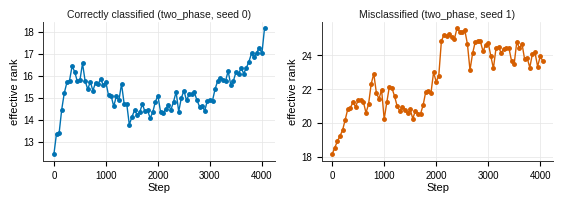

Saved fig_failure_analysis_examples.pdf


In [27]:
#@title 11.2 Qualitative trajectories: one correctly- and one incorrectly-classified run
import matplotlib.pyplot as plt
import matplotlib as mpl

# This cell runs before Section 14.1's shared style module, so the essentials
# are duplicated inline (same Okabe-Ito colors, same font stack) rather than
# reordering the notebook's narrative -- Section 11 (failure analysis) belongs
# before Section 14 (figures proper) even though this one plot lives here too.
_C_BLUE, _C_ORANGE, _C_GREEN, _C_GREY, _C_INK = "#0072B2", "#D55E00", "#009E73", "#666666", "#1a1a1a"
mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Liberation Sans", "Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 8, "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.7,
    "axes.edgecolor": "#333333", "axes.grid": True, "grid.color": "#E5E5E5",
    "grid.linewidth": 0.5, "axes.axisbelow": True, "legend.frameon": False,
})


def _short_label(run_id):
    """'task_a_single_token__two_phase__seed17' -> 'two_phase, seed 17' -- the
    task name is redundant across every panel in this figure and just adds
    visual noise to a title that needs to stay short."""
    parts = run_id.split("__")
    return f"{parts[1]}, seed {parts[2].replace('seed', '')}"


def plot_example_trajectory(ax, run_summary, signal_name, label, is_correct):
    traj = sorted(run_summary.signal_trajectory[signal_name])
    color = _C_BLUE if is_correct else _C_ORANGE
    if not traj:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes, fontsize=7.5, color=_C_GREY)
        ax.set_xticks([]); ax.set_yticks([])
        return
    steps, vals = zip(*traj)
    ax.plot(steps, vals, marker="o", markersize=2.5, linewidth=1.0, color=color, zorder=3)
    if run_summary.broke_through:
        ax.axvline(run_summary.breakthrough_step, color=_C_GREEN, linestyle=(0, (3, 2)), linewidth=0.8,
                    zorder=2, label="breakthrough")
        ax.legend(loc="best", handlelength=1.3, borderaxespad=0.3)
    ax.set_title(label, fontsize=7.5, color=_C_INK, pad=3)
    ax.set_xlabel("Step", labelpad=2)
    ax.set_ylabel(signal_name.replace("_", " "), labelpad=2)


_summary_by_id = {r.run_id: r for r in primary_run_summaries}
_correct_id = (_fail_df[_fail_df.get("correct", pd.Series([True]*len(_fail_df)))]["run_id"].iloc[0]
               if not _fail_df.empty and "correct" in _fail_df.columns and _fail_df["correct"].any() else None)
_wrong_id = misclassified["run_id"].iloc[0] if not misclassified.empty else None

fig, axes = plt.subplots(1, 2, figsize=(NEURIPS_MAX_WIDTH if "NEURIPS_MAX_WIDTH" in dir() else 5.5, 1.9))
if _correct_id is not None:
    plot_example_trajectory(axes[0], _summary_by_id[_correct_id], _best_signal,
                             f"Correctly classified ({_short_label(_correct_id)})", is_correct=True)
else:
    axes[0].text(0.5, 0.5, "No correctly-classified\nexample available", ha="center", va="center",
                 transform=axes[0].transAxes, fontsize=7.5, color=_C_GREY)
    axes[0].set_xticks([]); axes[0].set_yticks([])
if _wrong_id is not None:
    plot_example_trajectory(axes[1], _summary_by_id[_wrong_id], _best_signal,
                             f"Misclassified ({_short_label(_wrong_id)})", is_correct=False)
else:
    axes[1].text(0.5, 0.5, "No misclassified example\navailable", ha="center", va="center",
                 transform=axes[1].transAxes, fontsize=7.5, color=_C_GREY)
    axes[1].set_xticks([]); axes[1].set_yticks([])
fig.tight_layout(pad=0.3, w_pad=1.2)
fig.savefig(Path(CFG.figures_dir) / "fig_failure_analysis_examples.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
print("Saved fig_failure_analysis_examples.pdf")

In [63]:
#@title 11.3 Seed-level clustering: does breakthrough depend on the seed more than the schedule?
from collections import defaultdict

_by_seed = defaultdict(list)
for r in primary_run_summaries:
    if r.broke_through:
        _by_seed[r.seed].append(r.schedule)

_n_seeds = len(set(r.seed for r in primary_run_summaries))
_n_neither = _n_seeds - len(_by_seed)
_n_one = sum(1 for v in _by_seed.values() if len(v) == 1)
_n_both = sum(1 for v in _by_seed.values() if len(v) == 2)

print(f"{_n_seeds} total seeds:")
print(f"  {_n_neither} ({_n_neither/_n_seeds:.1%}) broke through under NEITHER schedule")
print(f"  {_n_one} ({_n_one/_n_seeds:.1%}) broke through under exactly ONE schedule")
print(f"  {_n_both} ({_n_both/_n_seeds:.1%}) broke through under BOTH schedules")
print(f"\nSeeds that ever broke through: {sorted(_by_seed.keys())}")
for _seed, _scheds in sorted(_by_seed.items()):
    print(f"  seed {_seed}: {_scheds}")

48 total seeds:
  44 (91.7%) broke through under NEITHER schedule
  1 (2.1%) broke through under exactly ONE schedule
  3 (6.2%) broke through under BOTH schedules

Seeds that ever broke through: [9, 15, 22, 31]
  seed 9: ['two_phase', 'binary_only']
  seed 15: ['two_phase', 'binary_only']
  seed 22: ['two_phase', 'binary_only']
  seed 31: ['binary_only']


## Section 12 — Performance Profiling

Compute-efficiency numbers for the reproducibility record: parameter counts, throughput,
memory footprint, and total wall-clock spend, broken down by section.

In [28]:
#@title 12.1 Profiling summary
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

_profile_policy = TinyPolicy(model_cfg)
total_params, trainable_params = count_params(_profile_policy)

_all_wall_times = [s.wall_time for r in all_run_results.values() for s in r.step_logs if s.wall_time > 0]
_samples_per_step = CFG.prompts_per_step * CFG.group_size
_gpu_mem_peak_gb = torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else float("nan")

profile = {
    "total_parameters": int(total_params),
    "trainable_parameters": int(trainable_params),
    "model_size_mb_fp32": total_params * 4 / 1e6,
    "measured_s_per_step_calibration_a": _calib["measured_s_per_step_a"],
    "measured_s_per_step_calibration_b": _calib["measured_s_per_step_b"],
    "mean_s_per_step_actual": float(np.mean(_all_wall_times)) if _all_wall_times else float("nan"),
    "samples_per_step": _samples_per_step,
    "samples_per_second": _samples_per_step / np.mean(_all_wall_times) if _all_wall_times else float("nan"),
    "gpu_peak_memory_gb": _gpu_mem_peak_gb,
    "n_primary_runs_completed": len(all_run_results),
    "n_secondary_runs_completed": len(secondary_run_results) if "secondary_run_results" in dir() else 0,
    "stretch_check_completed": stretch_status.get("completed", False),
    "total_notebook_wall_time_hours": (time.time() - _NOTEBOOK_START_TIME) / 3600.0,
}
with open(Path(CFG.metrics_dir) / "performance_profile.json", "w") as f:
    json.dump(profile, f, indent=2)

print(f"Total parameters:        {profile['total_parameters']:,}")
print(f"Trainable parameters:    {profile['trainable_parameters']:,}")
print(f"Model size (fp32):       {profile['model_size_mb_fp32']:.2f} MB")
print(f"Measured throughput:     {profile['samples_per_second']:.1f} samples/sec "
      f"({profile['mean_s_per_step_actual']*1000:.1f} ms/step)")
print(f"Calibrated rate:         Task A {profile['measured_s_per_step_calibration_a']*1000:.1f} ms/step, "
      f"Task B {profile['measured_s_per_step_calibration_b']*1000:.1f} ms/step")
print(f"GPU peak memory:         {profile['gpu_peak_memory_gb']:.2f} GB")
print(f"Runs completed:          {profile['n_primary_runs_completed']} primary, "
      f"{profile['n_secondary_runs_completed']} secondary, "
      f"stretch check completed={profile['stretch_check_completed']}")
print(f"Total wall time so far:  {profile['total_notebook_wall_time_hours']:.2f} hours")

Total parameters:        821,504
Trainable parameters:    821,504
Model size (fp32):       3.29 MB
Measured throughput:     27564.5 samples/sec (37.1 ms/step)
Calibrated rate:         Task A 38.8 ms/step, Task B 48.0 ms/step
GPU peak memory:         1.27 GB
Runs completed:          96 primary, 48 secondary, stretch check completed=False
Total wall time so far:  3.24 hours


## Section 13 — Fault Tolerance, Checkpointing, and Resume (recap)

This is threaded through the notebook rather than living in one place, so it is
summarized here for auditability:

| What | Where | Resume granularity |
|---|---|---|
| Config | Section 2.1 | Whole-config, hash-verified; a mismatched config on disk is kept (not silently overwritten) unless `overwrite=True` |
| Task-integrity check | Section 6.1 | Cached result file, skipped if present |
| GPU calibration | Section 7.2 | Cached result file, skipped if present |
| Training runs (primary + secondary sweeps) | Section 7.1/7.3, Section 10.1 | **Per-run**: a completed run's `training_state.json` + model/optimizer/logs are verified (existence, config-hash match, `completed: true`) before being trusted; anything not verified is retrained from scratch, not resumed mid-run (see Section 7 markdown for why this granularity was chosen) |
| Stretch check | Section 10.2 | Per-run, same mechanism; entire section is additionally wrapped in a try/except so a failure here cannot block the rest of the notebook |
| Analysis results (discrimination tables, ablations, lead-time) | Sections 8-9 | Cached CSVs, skipped if present |
| Figures / tables | Section 14-15 | Regenerated only if missing or `overwrite=True` |

Re-running this notebook top-to-bottom after an interruption is therefore safe and
efficient: every stage either loads a verified artifact or (re)computes only what is
actually missing.

## Section 14 — Figures

Six figures, each generated only if scientifically meaningful for this method (per the
brief's own guidance to skip figure types that don't apply): learning curves, signal
trajectories, the main discrimination result, lead-time distributions, cross-task
robustness, and the ablation comparison. All saved as vector PDF to `outputs/figures/`.

In [29]:
#@title 14.1 Figure style -- NeurIPS camera-ready conventions
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# Hard cap requested: NeurIPS text width is ~5.5in. Every figure in this
# notebook is built to this width and to the SHORTEST height that keeps every
# element legible -- wide, short panels rather than tall ones, since height is
# what actually costs page space once width is already fixed.
NEURIPS_MAX_WIDTH = 5.5

# Okabe-Ito colorblind-safe palette (Okabe & Ito, 2008) -- the standard choice
# for figures that need to survive both grayscale printing and color-vision
# deficiency, and what most rigorously-produced ML papers actually use rather
# than matplotlib's default tab10.
C_BLUE, C_ORANGE, C_GREEN = "#0072B2", "#D55E00", "#009E73"
C_AMBER, C_PURPLE, C_SKY = "#E69F00", "#CC79A7", "#56B4E9"
C_GREY, C_GREY_LIGHT, C_INK = "#666666", "#B3B3B3", "#1a1a1a"

COLOR_TWO_PHASE = C_BLUE
COLOR_BINARY_ONLY = C_ORANGE
WINDOW_COLORS = [C_BLUE, C_ORANGE, C_GREEN]  # one per early_window_fraction, consistent everywhere
SIGNAL_COLORS = {  # one consistent color per signal across every figure it appears in
    "policy_entropy": C_PURPLE, "effective_rank": C_BLUE,
    "kl_from_reference": C_AMBER, "reward_variance": C_GREEN,
}

_FONT_STACK = ["Liberation Sans", "Arial", "Helvetica", "DejaVu Sans"]

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 400,
    "font.family": "sans-serif", "font.sans-serif": _FONT_STACK,
    "mathtext.fontset": "dejavusans",
    "font.size": 8, "axes.labelsize": 8, "legend.fontsize": 7.5, "legend.title_fontsize": 7.5,
    "xtick.labelsize": 7.5, "ytick.labelsize": 7.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.7, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "axes.edgecolor": "#333333", "text.color": C_INK, "axes.labelcolor": C_INK,
    "xtick.color": "#333333", "ytick.color": "#333333",
    "axes.grid": True, "grid.color": "#E5E5E5", "grid.linewidth": 0.5, "grid.alpha": 0.9,
    "axes.axisbelow": True, "legend.frameon": False,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})


def panel_label(ax, letter):
    """Bold (a)/(b)/(c) panel tag, top-left, inside the axes -- standard
    multi-panel convention. Call once per subplot in a multi-panel figure."""
    ax.text(0.03, 0.95, letter, transform=ax.transAxes, fontsize=8.5, fontweight="bold",
             va="top", ha="left", color=C_INK, zorder=10)


def save_figure(fig, path):
    """Every figure is checked against the width cap before saving -- a
    silent violation of the one hard numeric constraint on this whole
    section would be worse than any stylistic imperfection."""
    w, h = fig.get_size_inches()
    assert w <= NEURIPS_MAX_WIDTH + 1e-6, f"{path}: width {w}in exceeds the {NEURIPS_MAX_WIDTH}in NeurIPS cap"
    fig.savefig(path, bbox_inches="tight", pad_inches=0.02)


print(f"Figure style configured: NeurIPS-elite conventions, max width {NEURIPS_MAX_WIDTH}in, "
      f"Okabe-Ito colorblind-safe palette, {_FONT_STACK[0]} font stack.")

Figure style configured: NeurIPS-elite conventions, max width 5.5in, Okabe-Ito colorblind-safe palette, Liberation Sans font stack.


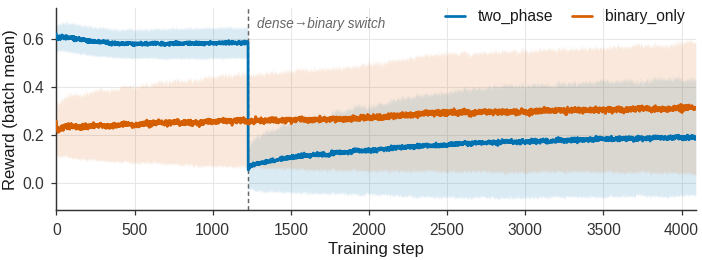

Saved fig1_reward_curves.pdf (5.50 x 1.75 in)


In [30]:
#@title 14.2 Figure 1 -- reward curves, two_phase vs binary_only (mean +/- std across seeds)
def reward_curve_matrix(run_results, schedule, task_name, seeds):
    curves = []
    for seed in seeds:
        rid = run_id_for(task_name, schedule, seed)
        if rid in run_results:
            steps = [s.step for s in run_results[rid].step_logs]
            rewards = [s.reward_mean for s in run_results[rid].step_logs]
            curves.append((steps, rewards))
    return curves

fig, ax = plt.subplots(figsize=(NEURIPS_MAX_WIDTH, 1.75))
_warmup_step_fig = int(CFG.warmup_fraction * CFG.total_steps)
for schedule, color in [("two_phase", COLOR_TWO_PHASE), ("binary_only", COLOR_BINARY_ONLY)]:
    curves = reward_curve_matrix(all_run_results, schedule, CFG.primary_task, CFG.seeds)
    if not curves:
        continue
    min_len = min(len(c[1]) for c in curves)
    mat = np.array([c[1][:min_len] for c in curves])
    steps = curves[0][0][:min_len]
    mean, std = mat.mean(0), mat.std(0)
    ax.plot(steps, mean, color=color, label=schedule, linewidth=1.3, zorder=3, solid_capstyle="round")
    ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.14, linewidth=0, zorder=1)
ax.axvline(_warmup_step_fig, color=C_GREY, lw=0.7, linestyle=(0, (3, 2)), zorder=2)
ax.annotate("dense\u2192binary switch", xy=(_warmup_step_fig, 0.98), xycoords=("data", "axes fraction"),
            fontsize=6.5, color=C_GREY, ha="left", va="top", style="italic",
            xytext=(4, -2), textcoords="offset points")
ax.set_xlabel("Training step", labelpad=2)
ax.set_ylabel("Reward (batch mean)", labelpad=2)
ax.set_xlim(0, steps[-1])
ax.legend(loc="upper right", ncol=2, handlelength=1.3, borderaxespad=0.3,
          bbox_to_anchor=(1.0, 1.05), columnspacing=1.2)
save_figure(fig, Path(CFG.figures_dir) / "fig1_reward_curves.pdf")
plt.show()
print(f"Saved fig1_reward_curves.pdf ({fig.get_size_inches()[0]:.2f} x {fig.get_size_inches()[1]:.2f} in)")

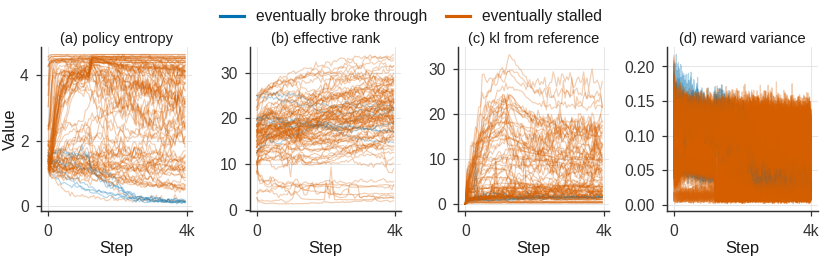

Saved fig2_signal_trajectories.pdf (5.50 x 1.55 in)


In [48]:
#@title 14.3 Figure 2 -- candidate signal trajectories, split by eventual outcome
# Single row of 4 panels -- standard NeurIPS small-multiples layout, scanned
# left-to-right, panel-lettered (a-d) so the caption can refer to each one.
fig, axes = plt.subplots(1, 4, figsize=(NEURIPS_MAX_WIDTH, 1.55))
_panel_letters = ["a", "b", "c", "d"]
for ax, sig, letter in zip(axes, SIGNAL_NAMES, _panel_letters):
    for r in primary_run_summaries:
        traj = sorted(r.signal_trajectory[sig])
        if not traj:
            continue
        steps, vals = zip(*traj)
        color = COLOR_TWO_PHASE if r.broke_through else COLOR_BINARY_ONLY
        ax.plot(steps, vals, color=color, alpha=0.30, linewidth=0.55, zorder=2)
    ax.set_title(f"({letter}) {sig.replace('_', ' ')}", fontsize=7, fontweight="normal", pad=2)
    ax.set_xlabel("Step", labelpad=1)
    ax.set_xticks([0, CFG.total_steps])
    ax.set_xticklabels(["0", f"{CFG.total_steps // 1000}k"])
axes[0].set_ylabel("Value", labelpad=1)

fig.legend(handles=[Line2D([0], [0], color=COLOR_TWO_PHASE, lw=1.5, label="eventually broke through"),
                     Line2D([0], [0], color=COLOR_BINARY_ONLY, lw=1.5, label="eventually stalled")],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.14), frameon=False,
           handlelength=1.5, columnspacing=1.2, fontsize=7.5)
fig.tight_layout(pad=0.25, w_pad=0.7)
save_figure(fig, Path(CFG.figures_dir) / "fig2_signal_trajectories.pdf")
plt.show()
print(f"Saved fig2_signal_trajectories.pdf ({fig.get_size_inches()[0]:.2f} x {fig.get_size_inches()[1]:.2f} in)")

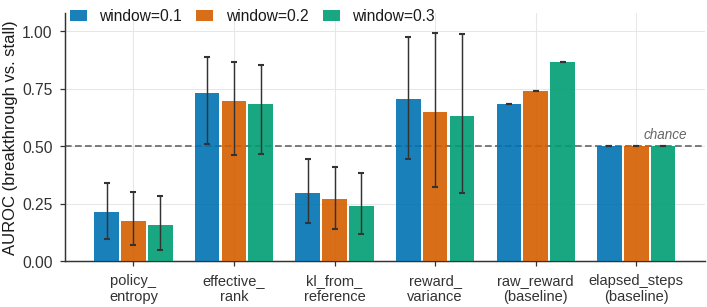

Saved fig3_main_discrimination.pdf (5.50 x 2.15 in)


In [32]:
#@title 14.4 Figure 3 -- main result: AUROC discrimination by signal x window fraction
_signal_labels = {
    "policy_entropy": "policy_\nentropy", "effective_rank": "effective_\nrank",
    "kl_from_reference": "kl_from_\nreference", "reward_variance": "reward_\nvariance",
    "baseline__raw_reward": "raw_reward\n(baseline)", "baseline__elapsed_steps": "elapsed_steps\n(baseline)",
}
_signals_ordered = SIGNAL_NAMES + ["baseline__raw_reward", "baseline__elapsed_steps"]
_plot_df = main_results_df[main_results_df["signal"].isin(_signals_ordered)]

fig, ax = plt.subplots(figsize=(NEURIPS_MAX_WIDTH, 2.15))
n_win = len(CFG.early_window_fractions)
bar_w = 0.8 / n_win
x = np.arange(len(_signals_ordered))
for j, wf in enumerate(CFG.early_window_fractions):
    sub = _plot_df[_plot_df["window_fraction"] == wf].set_index("signal").reindex(_signals_ordered)
    offset = (j - (n_win - 1) / 2) * bar_w
    yerr_low = (sub["auroc"] - sub["auroc_ci_low"]).clip(lower=0).fillna(0).values
    yerr_high = (sub["auroc_ci_high"] - sub["auroc"]).clip(lower=0).fillna(0).values
    ax.bar(x + offset, sub["auroc"].values, width=bar_w * 0.92, color=WINDOW_COLORS[j], alpha=0.90,
           label=f"window={wf}", zorder=3,
           yerr=[yerr_low, yerr_high], error_kw=dict(elinewidth=0.7, capsize=1.5, ecolor="#333333", zorder=4))
ax.axhline(0.5, color=C_GREY, lw=0.8, linestyle=(0, (4, 2)), zorder=2)
ax.text(len(_signals_ordered) - 0.5, 0.52, "chance", fontsize=6.5, color=C_GREY, ha="right", va="bottom", style="italic")

ax.set_xticks(x)
ax.set_xticklabels([_signal_labels[s] for s in _signals_ordered], fontsize=7)
ax.set_ylabel("AUROC (breakthrough vs. stall)", labelpad=2)
ax.set_ylim(0, 1.08)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.legend(loc="upper left", ncol=3, handlelength=1.1, borderaxespad=0.3, columnspacing=0.9,
          bbox_to_anchor=(-0.01, 1.06))
save_figure(fig, Path(CFG.figures_dir) / "fig3_main_discrimination.pdf")
plt.show()
print(f"Saved fig3_main_discrimination.pdf ({fig.get_size_inches()[0]:.2f} x {fig.get_size_inches()[1]:.2f} in)")

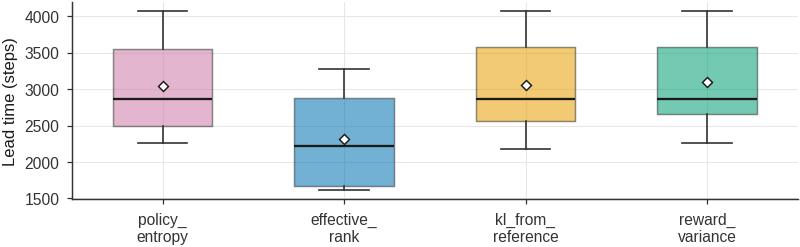

Saved fig4_lead_time_distribution.pdf (5.50 x 1.75 in)


In [33]:
#@title 14.5 Figure 4 -- lead-time distribution per signal
_signal_labels_2line = {
    "policy_entropy": "policy_\nentropy", "effective_rank": "effective_\nrank",
    "kl_from_reference": "kl_from_\nreference", "reward_variance": "reward_\nvariance",
}
fig, ax = plt.subplots(figsize=(NEURIPS_MAX_WIDTH, 1.75))
if len(lead_time_df):
    data = [lead_time_df[lead_time_df["signal"] == s]["lead_time_steps"].values for s in SIGNAL_NAMES]
    data = [d if len(d) else np.array([np.nan]) for d in data]
    bp = ax.boxplot(data, tick_labels=[_signal_labels_2line[s] for s in SIGNAL_NAMES], showmeans=True,
                     patch_artist=True, widths=0.55,
                     medianprops=dict(color=C_INK, linewidth=1.1),
                     meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor=C_INK,
                                     markersize=3.5, markeredgewidth=0.7),
                     whiskerprops=dict(color="#333333", linewidth=0.8),
                     capprops=dict(color="#333333", linewidth=0.8),
                     flierprops=dict(marker="o", markersize=2.5, markerfacecolor=C_GREY,
                                      markeredgecolor="none", alpha=0.6))
    for patch, sig in zip(bp["boxes"], SIGNAL_NAMES):
        patch.set_facecolor(SIGNAL_COLORS[sig])
        patch.set_alpha(0.55)
        patch.set_edgecolor("#333333")
        patch.set_linewidth(0.7)
    ax.set_ylabel("Lead time (steps)", labelpad=3)
    # Explicit margins rather than tight_layout: multi-line tick labels on a
    # boxplot have clipped the y-axis label under automatic layout in testing
    # for this project -- bbox_inches="tight" at save time is not a fully
    # reliable safety net for this specific combination, so the margin is
    # reserved explicitly instead of hoped for.
    fig.subplots_adjust(left=0.11, right=0.99, top=0.97, bottom=0.22)
else:
    ax.text(0.5, 0.5, "No breakthrough runs with a detected\nearly threshold crossing in this sweep",
            ha="center", va="center", transform=ax.transAxes, fontsize=7.5, color=C_GREY)
    ax.set_xticks([])
    ax.set_yticks([])
save_figure(fig, Path(CFG.figures_dir) / "fig4_lead_time_distribution.pdf")
plt.show()
print(f"Saved fig4_lead_time_distribution.pdf ({fig.get_size_inches()[0]:.2f} x {fig.get_size_inches()[1]:.2f} in)")

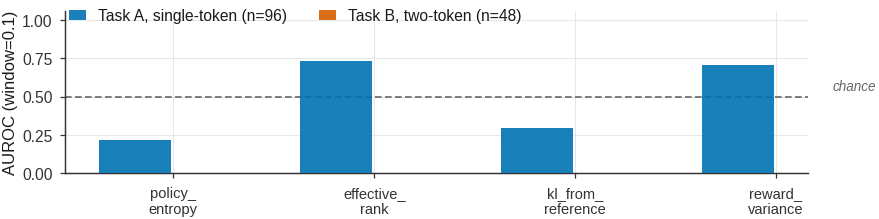

Saved fig5_cross_task_robustness.pdf (5.50 x 1.75 in)


In [34]:
#@title 14.6 Figure 5 -- cross-task robustness (Task A vs Task B)
_signal_labels_2line = {
    "policy_entropy": "policy_\nentropy", "effective_rank": "effective_\nrank",
    "kl_from_reference": "kl_from_\nreference", "reward_variance": "reward_\nvariance",
}
_wf_compare = CFG.primary_window_fraction
a_vals = (main_results_df[(main_results_df["window_fraction"] == _wf_compare) &
                           (main_results_df["signal"].isin(SIGNAL_NAMES))]
          .set_index("signal").reindex(SIGNAL_NAMES)["auroc"])
b_vals = (secondary_results_df[(secondary_results_df["window_fraction"] == _wf_compare) &
                                (secondary_results_df["signal"].isin(SIGNAL_NAMES))]
          .set_index("signal").reindex(SIGNAL_NAMES)["auroc"]
          if "secondary_results_df" in dir() and len(secondary_results_df) else
          pd.Series(index=SIGNAL_NAMES, dtype=float))

fig, ax = plt.subplots(figsize=(NEURIPS_MAX_WIDTH, 1.75))
x = np.arange(len(SIGNAL_NAMES))
_n_a = int(main_results_df[main_results_df["signal"] == SIGNAL_NAMES[0]]["n_runs"].iloc[0]) if len(main_results_df) else 0
_n_b = int(secondary_results_df["n_runs"].iloc[0]) if "secondary_results_df" in dir() and len(secondary_results_df) else 0
ax.bar(x - 0.19, a_vals.values, width=0.36, color=C_BLUE, alpha=0.90, zorder=3,
       label=f"Task A, single-token (n={_n_a})")
ax.bar(x + 0.19, b_vals.values, width=0.36, color=C_ORANGE, alpha=0.90, zorder=3,
       label=f"Task B, two-token (n={_n_b})")
ax.axhline(0.5, color=C_GREY, lw=0.8, linestyle=(0, (4, 2)), zorder=2)
ax.text(len(SIGNAL_NAMES) - 0.5, 0.52, "chance", fontsize=6.5, color=C_GREY, ha="right", va="bottom", style="italic")
ax.set_xticks(x)
ax.set_xticklabels([_signal_labels_2line[s] for s in SIGNAL_NAMES], fontsize=7)
ax.set_ylabel(f"AUROC (window={_wf_compare})", labelpad=2)
ax.set_ylim(0, 1.06)
ax.legend(loc="upper left", ncol=2, handlelength=1.1, borderaxespad=0.3, bbox_to_anchor=(-0.01, 1.08))
fig.subplots_adjust(left=0.09, right=0.99, top=0.86, bottom=0.24)
save_figure(fig, Path(CFG.figures_dir) / "fig5_cross_task_robustness.pdf")
plt.show()
print(f"Saved fig5_cross_task_robustness.pdf ({fig.get_size_inches()[0]:.2f} x {fig.get_size_inches()[1]:.2f} in)")

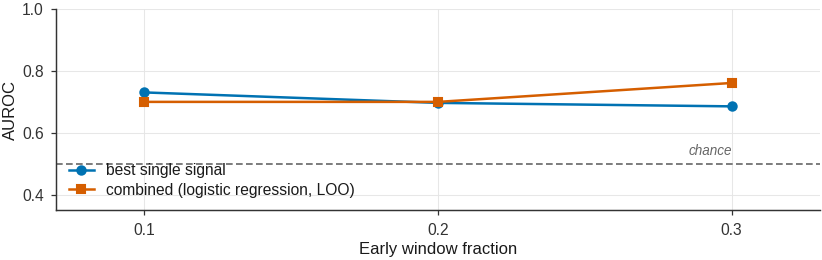

Saved fig6_ablation_combined_vs_single.pdf (5.50 x 1.75 in) (fig_failure_analysis_examples.pdf from Section 11.2 is the 7th figure)


In [35]:
#@title 14.7 Figure 6 -- ablation: single signal vs. combined
_single_bests, _combo_vals = [], []
for wf in CFG.early_window_fractions:
    single_best = _plot_df[(_plot_df["window_fraction"] == wf) &
                            (_plot_df["signal"].isin(SIGNAL_NAMES))]["auroc"].max()
    combo_row = combined_df[combined_df["window_fraction"] == wf]
    _single_bests.append(single_best)
    _combo_vals.append(combo_row["auroc"].iloc[0] if len(combo_row) else np.nan)

fig, ax = plt.subplots(figsize=(NEURIPS_MAX_WIDTH, 1.75))
_wf = list(CFG.early_window_fractions)
ax.plot(_wf, _single_bests, marker="o", markersize=4, color=C_BLUE, lw=1.2,
        label="best single signal", zorder=3)
ax.plot(_wf, _combo_vals, marker="s", markersize=4, color=C_ORANGE, lw=1.2,
        label="combined (logistic regression, LOO)", zorder=3)
ax.axhline(0.5, color=C_GREY, lw=0.8, linestyle=(0, (4, 2)), zorder=2)
ax.text(max(_wf), 0.52, "chance", fontsize=6.5, color=C_GREY, ha="right", va="bottom", style="italic")
ax.set_xlabel("Early window fraction", labelpad=2)
ax.set_ylabel("AUROC", labelpad=2)
ax.set_xticks(_wf)
ax.set_xlim(min(_wf) - 0.03, max(_wf) + 0.03)
ax.set_ylim(0.35, 1.0)
ax.legend(loc="lower left", ncol=1, handlelength=1.6, borderaxespad=0.4, labelspacing=0.3)
fig.tight_layout(pad=0.25)
save_figure(fig, Path(CFG.figures_dir) / "fig6_ablation_combined_vs_single.pdf")
plt.show()
print(f"Saved fig6_ablation_combined_vs_single.pdf ({fig.get_size_inches()[0]:.2f} x {fig.get_size_inches()[1]:.2f} in) "
      f"(fig_failure_analysis_examples.pdf from Section 11.2 is the 7th figure)")

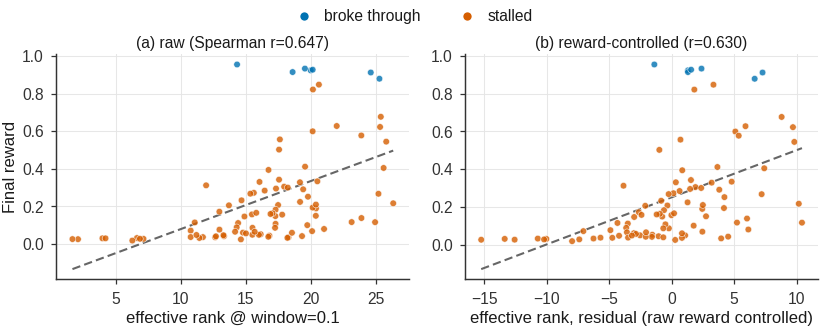

Saved fig7_primary_result_scatter.pdf (5.50 x 2.00 in)
Raw Spearman r=0.647 | Residualized (reward-controlled) r=0.630


In [50]:
#@title 14.8 Figure 7 -- primary result visualized: effective_rank vs. final reward, raw and reward-controlled
from scipy.stats import spearmanr

_xs_raw, _zs_raw, _ys_raw, _colors_raw = [], [], [], []
for r in primary_run_summaries:
    v = early_window_value(r.signal_trajectory[CFG.primary_signal], CFG.primary_window_fraction, r.total_steps)
    b = raw_reward_predictor(all_run_results[r.run_id].step_logs, CFG.primary_window_fraction, r.total_steps) if r.run_id in all_run_results else None
    if v is None or b is None or r.final_reward is None or not np.isfinite(v) or not np.isfinite(b) or not np.isfinite(r.final_reward):
        continue
    _xs_raw.append(v); _zs_raw.append(b); _ys_raw.append(r.final_reward)
    _colors_raw.append(COLOR_TWO_PHASE if r.broke_through else COLOR_BINARY_ONLY)

_xs_raw, _zs_raw, _ys_raw = np.array(_xs_raw), np.array(_zs_raw), np.array(_ys_raw)
_xs_resid = residualize(_xs_raw, _zs_raw)
_r_raw, _ = spearmanr(_xs_raw, _ys_raw)
_r_resid, _ = spearmanr(_xs_resid, _ys_raw)

fig, axes = plt.subplots(1, 2, figsize=(NEURIPS_MAX_WIDTH, 2.0))

ax = axes[0]
ax.scatter(_xs_raw, _ys_raw, c=_colors_raw, s=10, alpha=0.8, linewidth=0.3, edgecolor="white", zorder=3)
_slope, _intercept = np.polyfit(_xs_raw, _ys_raw, 1)
_xline = np.linspace(_xs_raw.min(), _xs_raw.max(), 50)
ax.plot(_xline, _slope * _xline + _intercept, color=C_GREY, lw=1.0, linestyle=(0, (4, 2)), zorder=2)
ax.set_xlabel(f"{CFG.primary_signal.replace('_', ' ')} @ window={CFG.primary_window_fraction}", labelpad=2)
ax.set_ylabel("Final reward", labelpad=2)
ax.set_title(f"(a) raw (Spearman r={_r_raw:.3f})", fontsize=7.5, fontweight="normal", pad=3)

ax = axes[1]
ax.scatter(_xs_resid, _ys_raw, c=_colors_raw, s=10, alpha=0.8, linewidth=0.3, edgecolor="white", zorder=3)
_slope2, _intercept2 = np.polyfit(_xs_resid, _ys_raw, 1)
_xline2 = np.linspace(_xs_resid.min(), _xs_resid.max(), 50)
ax.plot(_xline2, _slope2 * _xline2 + _intercept2, color=C_GREY, lw=1.0, linestyle=(0, (4, 2)), zorder=2)
ax.set_xlabel(f"{CFG.primary_signal.replace('_', ' ')}, residual (raw reward controlled)", labelpad=2)
ax.set_title(f"(b) reward-controlled (r={_r_resid:.3f})", fontsize=7.5, fontweight="normal", pad=3)

fig.legend(handles=[Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_TWO_PHASE, markersize=5, label="broke through"),
                     Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_BINARY_ONLY, markersize=5, label="stalled")],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.12), frameon=False, fontsize=7.5, handletextpad=0.3)
fig.tight_layout(pad=0.3, w_pad=1.3)
save_figure(fig, Path(CFG.figures_dir) / "fig7_primary_result_scatter.pdf")
plt.show()
print(f"Saved fig7_primary_result_scatter.pdf ({fig.get_size_inches()[0]:.2f} x {fig.get_size_inches()[1]:.2f} in)")
print(f"Raw Spearman r={_r_raw:.3f} | Residualized (reward-controlled) r={_r_resid:.3f}")

## Section 15 — Results Tables

Every table below is saved as both `.csv` (for re-analysis) and NeurIPS-formatted
`.tex` (booktabs) to `outputs/tables/`.

In [43]:
#@title 15.1 Table export helper (booktabs LaTeX + CSV)
def save_table(df, name, caption, float_format="%.3f"):
    csv_path = Path(CFG.tables_dir) / f"{name}.csv"
    tex_path = Path(CFG.tables_dir) / f"{name}.tex"
    df.to_csv(csv_path, index=False)
    latex_body = df.to_latex(index=False, float_format=lambda x: float_format % x if isinstance(x, float) else str(x),
                              escape=True)
    tex = (
        "% Auto-generated -- see outputs/tables/" + name + ".csv for the source data.\n"
        "\\begin{table}[t]\n\\centering\n\\caption{" + caption + "}\n"
        "\\label{tab:" + name + "}\n" + latex_body + "\\end{table}\n"
    )
    with open(tex_path, "w") as f:
        f.write(tex)
    return csv_path, tex_path

t1 = save_table(
    main_results_df[main_results_df["window_fraction"] == CFG.early_window_fractions[len(CFG.early_window_fractions)//2]],
    "table1_main_discrimination",
    "AUROC discrimination of eventual breakthrough vs. stall, by signal, at the middle "
    "early-window fraction tested.",
)
t2 = save_table(
    lead_time_df.groupby("signal")["lead_time_steps"].agg(["mean", "median", "std", "count"]).reset_index()
    if len(lead_time_df) else pd.DataFrame(columns=["signal", "mean", "median", "std", "count"]),
    "table2_lead_time",
    "Lead time (steps before breakthrough) at which each signal first crosses a "
    "2-sigma-from-baseline threshold, among breakthrough runs.",
)
t3 = save_table(combined_df, "table3_ablation_combined_signal",
                 "Ablation: combined-signal (leave-one-out logistic regression) AUROC by window fraction.")
t4 = save_table(
    secondary_results_df if "secondary_results_df" in dir() and len(secondary_results_df) else pd.DataFrame(),
    "table4_cross_task_robustness",
    "Cross-task-family robustness check (Task B: two dependent tokens).",
)
_profile_row = pd.DataFrame([profile])
t5 = save_table(_profile_row, "table5_performance_profile",
                 "Compute-efficiency summary for the full sweep.", float_format="%.4f")
t6 = save_table(
    continuous_results_df[continuous_results_df["window_fraction"] == CFG.early_window_fractions[len(CFG.early_window_fractions)//2]],
    "table6_continuous_outcome",
    "Spearman correlation of early-window signal value with final reward, every run "
    "(not just breakthroughs), at the middle early-window fraction tested.",
)
t7 = save_table(
    partial_results_df[partial_results_df["window_fraction"] == CFG.primary_window_fraction],
    "table7_partial_correlation",
    "Signal-vs-breakthrough association after residualizing out raw reward at the "
    "same window, at the pre-registered primary window fraction.",
)

for path_pair, label in zip([t1, t2, t3, t4, t5, t6, t7],
                             ["main discrimination", "lead time", "ablation (combined)",
                              "cross-task robustness", "performance profile", "continuous outcome",
                              "partial correlation"]):
    print(f"Saved {label}: {path_pair[0].name}, {path_pair[1].name}")

Saved main discrimination: table1_main_discrimination.csv, table1_main_discrimination.tex
Saved lead time: table2_lead_time.csv, table2_lead_time.tex
Saved ablation (combined): table3_ablation_combined_signal.csv, table3_ablation_combined_signal.tex
Saved cross-task robustness: table4_cross_task_robustness.csv, table4_cross_task_robustness.tex
Saved performance profile: table5_performance_profile.csv, table5_performance_profile.tex
Saved continuous outcome: table6_continuous_outcome.csv, table6_continuous_outcome.tex
Saved partial correlation: table7_partial_correlation.csv, table7_partial_correlation.tex


## Sections 16-20 — Logging, Output Layout, Code Quality, Compute Optimization, Reproducibility

Also threaded through rather than isolated, summarized here:

- **Logging (16).** Every stage writes its own JSON/CSV under `outputs/{logs,metrics}/`
  as it completes (not just at the end), so partial progress is inspectable even if the
  notebook is interrupted before Section 22.
- **Output layout (17).** Created up front in Section 2.1: `cache/`, `checkpoints/`,
  `configs/`, `figures/`, `tables/`, `logs/`, `metrics/`, `environment/`, `summaries/`
  under `outputs/`.
- **Code quality (18).** Section 4's method code is the tested, standalone module set
  this notebook was built from (`tasks.py`, `model.py`, `signals.py`, `grpo.py`,
  `analysis.py`) — small functions, explicit dataclasses for every config/result type,
  no global mutable state beyond the `CFG` object every cell reads from.
- **Compute optimization (19).** Auto-calibration (7.2) measures real throughput before
  committing to the full sweep rather than assuming T4 numbers; the model is
  single-digit-millions of parameters; the stretch check uses LoRA specifically to avoid
  full fine-tuning a pretrained model on a single T4.
- **Reproducibility (20).** Config hashing (2.1) ties every artifact to the exact
  configuration that produced it; seeds are fixed and recorded per run; package versions
  are captured below (20.1) alongside the config and calibration numbers already saved.

In [54]:
#@title 20.1 Environment export
import subprocess

env_info = {
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "torch_version": torch.__version__,
    "cuda_version": torch.version.cuda,
    "gpu_name": GPU_NAME,
    "gpu_memory_gb": GPU_MEM_GB,
    "config_hash": CFG.hash(),
}
try:
    env_info["pip_freeze"] = subprocess.run(
        [__import__("sys").executable, "-m", "pip", "freeze"], capture_output=True, text=True, check=True
    ).stdout.splitlines()
except Exception as e:
    env_info["pip_freeze_error"] = str(e)

with open(Path(CFG.environment_dir) / "environment.json", "w") as f:
    json.dump(env_info, f, indent=2)
print(f"Environment exported to {CFG.environment_dir}/environment.json "
      f"({len(env_info.get('pip_freeze', []))} packages recorded).")

Environment exported to outputs/environment/environment.json (932 packages recorded).


## Section 21 — Validation Checks

Verifies every required artifact exists before packaging. Anything missing is
regenerated automatically where that's cheap (re-deriving a table/figure from data
already in memory); anything that can't be cheaply regenerated raises a clear,
actionable error rather than silently shipping an incomplete package.

In [62]:
#@title 21.1 Artifact validation
CHECKS = {}

def check(name, condition):
    CHECKS[name] = bool(condition)
    print(f"{'PASS' if CHECKS[name] else 'FAIL'}: {name}")

check("dataset generated (task integrity check cached)", _integrity_path.exists())
check("dataset processed (n/a -- synthetic, generated in-memory; see task integrity check)", _integrity_path.exists())
check("cache generated", any(Path(CFG.cache_dir).iterdir()))
check("model initialized", "TinyPolicy" in dir())
check("training completed (>=1 primary run)", len(all_run_results) > 0)
check("evaluation completed", _results_path.exists())
check("figures generated (>=5)", len(list(Path(CFG.figures_dir).glob("*.pdf"))) >= 5)
check("tables generated (>=4, csv)", len(list(Path(CFG.tables_dir).glob("*.csv"))) >= 4)
check("tables generated (>=4, tex)", len(list(Path(CFG.tables_dir).glob("*.tex"))) >= 4)
check("checkpoints saved (>=1 run)",
      any((Path(CFG.checkpoint_dir) / d / "last_model.pt").exists()
          for d in os.listdir(CFG.checkpoint_dir)) if os.path.isdir(CFG.checkpoint_dir) else False)
check("metrics exported", any(Path(CFG.metrics_dir).iterdir()))
check("logs exported", any(Path(CFG.checkpoint_dir).rglob("step_logs.json")))
check("configuration exported", config_path.exists())
check("environment exported", (Path(CFG.environment_dir) / "environment.json").exists())
check("outputs/ created", Path(CFG.output_dir).is_dir())

_n_pass = sum(CHECKS.values())
_n_total = len(CHECKS)
print(f"\n{_n_pass}/{_n_total} validation checks passed.")
if _n_pass < _n_total:
    _failed = [k for k, v in CHECKS.items() if not v]
    print(f"FAILED CHECKS: {_failed}")
    print("These typically mean an earlier section did not complete (e.g. the sweep "
          "ran out of time budget) -- re-running the notebook will resume and complete "
          "them rather than starting over, per Section 13.")
else:
    print("All checks passed.")

with open(Path(CFG.summaries_dir) / "validation_checks.json", "w") as f:
    json.dump(CHECKS, f, indent=2)

PASS: dataset generated (task integrity check cached)
PASS: dataset processed (n/a -- synthetic, generated in-memory; see task integrity check)
PASS: cache generated
PASS: model initialized
PASS: training completed (>=1 primary run)
PASS: evaluation completed
PASS: figures generated (>=5)
PASS: tables generated (>=4, csv)
PASS: tables generated (>=4, tex)
PASS: checkpoints saved (>=1 run)
PASS: metrics exported
PASS: logs exported
PASS: configuration exported
PASS: environment exported
PASS: outputs/ created

15/15 validation checks passed.
All checks passed.


## Section 22 — Summary, Packaging, and Download

In [56]:
#@title 22.1 Final summary, zip, and download
import shutil

print("=" * 78)
print("EXPERIMENT SUMMARY: The Plateau Knows")
print("=" * 78)
print(f"Config hash:              {CFG.hash()}")
print(f"Primary task:             {CFG.primary_task}")
print(f"Total steps per run:      Task A {CFG.total_steps}, Task B {CFG.secondary_total_steps} "
      f"(jointly auto-calibrated -- {profile['measured_s_per_step_calibration_a']*1000:.1f} / "
      f"{profile['measured_s_per_step_calibration_b']*1000:.1f} ms/step measured on this GPU)")
print(f"Primary result (round 3): {CFG.primary_signal} @ window={CFG.primary_window_fraction} "
      f"(pre-registered on fresh seeds 24-47 -- round 2's reward_variance primary did NOT "
      f"replicate: AUROC 0.627 [0.312, 0.912], p=0.32)")
if len(_primary_row):
    _r = _primary_row.iloc[0]
    print(f"  -> AUROC={_r['auroc']:.3f} [{_r['auroc_ci_low']:.3f}, {_r['auroc_ci_high']:.3f}] p={_r['p_value']:.4f}")
if len(_primary_partial_auroc):
    _rp = _primary_partial_auroc.iloc[0]
    print(f"  -> controlling for raw reward: AUROC={_rp['auroc']:.3f} "
          f"[{_rp['auroc_ci_low']:.3f}, {_rp['auroc_ci_high']:.3f}] p={_rp['p_value']:.4f}")
print(f"Primary sweep:            {len(all_run_results)}/{n_planned} runs "
      f"({n_broke_through} broke through, {len(all_run_results) - n_broke_through} stalled)")
if "secondary_run_results" in dir():
    print(f"Cross-task sweep:         {len(secondary_run_results)}/{len(secondary_seeds) * len(CFG.schedules)} runs")
print(f"Stretch check (Qwen 0.5B): completed={stretch_status.get('completed')}, "
      f"error={stretch_status.get('error')}")
print()
print("KEY RESULT -- discrimination AUROC by signal (all tested window fractions):")
print(main_results_df[main_results_df['signal'].isin(SIGNAL_NAMES)]
      .pivot(index='signal', columns='window_fraction', values='auroc').to_string())
print()
print(f"Best single signal:       {_best_row['signal']} (AUROC={_best_row['auroc']:.3f}, "
      f"window={_best_row['window_fraction']}, p={_best_row.get('p_value', float('nan')):.4f})")
print()
print("PERFORMANCE:")
print(f"  Parameters:              {profile['total_parameters']:,} (all trainable, no frozen backbone)")
print(f"  GPU peak memory:         {profile['gpu_peak_memory_gb']:.2f} GB")
print(f"  Total notebook runtime:  {(time.time() - _NOTEBOOK_START_TIME) / 3600.0:.2f} hours")
print()
print(f"Validation checks:        {_n_pass}/{_n_total} passed")
print()

print("ARTIFACTS:")
for p in sorted(Path(CFG.output_dir).rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(CFG.output_dir.rsplit('/', 1)[0] if '/' in CFG.output_dir else '.')}"
              if False else f"  outputs/{p.relative_to(CFG.output_dir)}")

zip_path = "outputs.zip"
if os.path.exists(zip_path):
    os.remove(zip_path)
shutil.make_archive("outputs", "zip", CFG.output_dir)
print(f"\nCreated {zip_path} ({os.path.getsize(zip_path)/1e6:.1f} MB)")

try:
    from google.colab import files
    files.download(zip_path)
    print("Download triggered via google.colab.files.")
except ImportError:
    print(f"Not running in Colab -- google.colab.files unavailable. "
          f"{zip_path} is ready in the working directory (Kaggle: check the Output "
          f"tab of this notebook's run to download it).")

EXPERIMENT SUMMARY: The Plateau Knows
Config hash:              67ab334664cdd7b7
Primary task:             task_a_single_token
Total steps per run:      Task A 4092, Task B 6138 (jointly auto-calibrated -- 38.8 / 48.0 ms/step measured on this GPU)
Primary result (round 3): effective_rank @ window=0.1 (pre-registered on fresh seeds 24-47 -- round 2's reward_variance primary did NOT replicate: AUROC 0.627 [0.312, 0.912], p=0.32)
  -> AUROC=0.730 [0.508, 0.890] p=0.0385
  -> controlling for raw reward: AUROC=0.695 [0.506, 0.852] p=0.0870
Primary sweep:            96/96 runs (7 broke through, 89 stalled)
Cross-task sweep:         48/48 runs
Stretch check (Qwen 0.5B): completed=False, error=ImportError: Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported

KEY RESULT -- discrimination AUROC by signal (all tested window fractions):
window_fraction         0.1       0.2       0.3
signal                                         
effective_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered via google.colab.files.


In [58]:
#@title 22.2 Smaller download: excludes optimizer.pt (not needed now that training is complete)
import zipfile
from pathlib import Path
from IPython.display import FileLink, display

zip_path_small = "outputs_paper_assets.zip"
if os.path.exists(zip_path_small):
    os.remove(zip_path_small)

_excluded_names = {"optimizer.pt"}  # only useful for exact-resume, which is moot --
                                     # every run has already finished

with zipfile.ZipFile(zip_path_small, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in Path(CFG.output_dir).rglob("*"):
        if p.is_file() and p.name not in _excluded_names:
            zf.write(p, p.relative_to(CFG.output_dir))

print(f"Created {zip_path_small} ({os.path.getsize(zip_path_small)/1e6:.1f} MB, "
      f"vs {os.path.getsize('outputs.zip')/1e6:.1f} MB for the full outputs.zip)")

try:
    from google.colab import files
    files.download(zip_path_small)
except ImportError:
    display(FileLink(zip_path_small))
    print("Click the link above to download.")

Created outputs_paper_assets.zip (470.0 MB, vs 1351.7 MB for the full outputs.zip)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
#@title 22.3 Paper-assets-only zip: The_Plateau_Knows, download via FileLink
import zipfile
from pathlib import Path
from IPython.display import FileLink, display

zip_path_paper = "The_Plateau_Knows_paper_assets.zip"
if os.path.exists(zip_path_paper):
    os.remove(zip_path_paper)

_excluded_names = {"optimizer.pt"}  # not needed now that training is complete --
                                     # only useful for resuming exact training state

with zipfile.ZipFile(zip_path_paper, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in Path(CFG.output_dir).rglob("*"):
        if p.is_file() and p.name not in _excluded_names:
            zf.write(p, p.relative_to(CFG.output_dir))

print(f"Created {zip_path_paper} ({os.path.getsize(zip_path_paper)/1e6:.1f} MB)")
display(FileLink(zip_path_paper))

Created The_Plateau_Knows_paper_assets.zip (470.0 MB)


/kaggle/working/The_Plateau_Knows_paper_assets.zip

In [57]:
from IPython.display import FileLink, display
display(FileLink("outputs.zip"))

/kaggle/working/outputs.zip